In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

In [2]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# Option 1: Based on data type
categorical_cols_dtype = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns based on dtype:", categorical_cols_dtype)

# Option 2: Based on number of unique values (heuristic)
# Here we consider columns with <=10 unique values as categorical
categorical_cols_unique = [col for col in df.columns if df[col].nunique() <= 10]
print("Categorical columns based on unique values:", categorical_cols_unique)


Categorical columns based on dtype: []
Categorical columns based on unique values: ['mental_health_history', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']


In [5]:
df.isnull().sum()


,0
anxiety_level,0
self_esteem,0
mental_health_history,0
depression,0
headache,0
blood_pressure,0
sleep_quality,0
breathing_problem,0
noise_level,0
living_conditions,0


In [6]:
# Get summary statistics of numerical columns
df.describe()


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [7]:
# Check value counts of the target column
target_col = 'stress_level'  # replace with your target variable
balance_check = df[target_col].value_counts()
percentage = df[target_col].value_counts(normalize=True) * 100

print("Value counts:\n", balance_check)
print("\nPercentage distribution:\n", percentage)


Value counts:
 stress_level
0    373
2    369
1    358
Name: count, dtype: int64

Percentage distribution:
 stress_level
0    33.909091
2    33.545455
1    32.545455
Name: proportion, dtype: float64


In [8]:
# Relabel stress_level values with meaningful names
label_map = {0: "Low Stress", 2: "High Stress", 1: "Medium Stress"}
df['stress_level'] = df['stress_level'].map(label_map)

# Check new distribution
value_counts = df['stress_level'].value_counts()
percentages = df['stress_level'].value_counts(normalize=True) * 100

print("Value counts:\n", value_counts)
print("\nPercentage distribution:\n", percentages)


Value counts:
 stress_level
Low Stress       373
High Stress      369
Medium Stress    358
Name: count, dtype: int64

Percentage distribution:
 stress_level
Low Stress       33.909091
High Stress      33.545455
Medium Stress    32.545455
Name: proportion, dtype: float64


In [9]:
pip install xgboost

In [10]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


In [11]:
pip install LightGBM

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# Target and features
target = 'stress_level'
X = df.drop(columns=[target])
y = df[target]

# Identify categorical and numerical columns
categorical_cols = [col for col in X.columns if X[col].nunique() <= 10]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Split data (prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100),
    'SVM': SVC(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

accuracies = {}


In [14]:
for name, model in models.items():
    # Create pipeline to avoid leakage
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    # Fit model
    clf.fit(X_train, y_train)
    # Predict
    y_pred = clf.predict(X_test)
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

print("Model Accuracies:")
for name, acc in accuracies.items():
    print(f"{name}: {acc:.4f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:19:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Accuracies:
Logistic Regression: 0.8818
Random Forest: 0.8864
Gradient Boosting: 0.8727
SVM: 0.8909
XGBoost: 0.8864


In [15]:
pip install tensorflow

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Preprocess for NN
X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)
y_train_nn = to_categorical(y_train)
y_test_nn = to_categorical(y_test)

# Neural network
nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn.fit(X_train_nn, y_train_nn, epochs=5, batch_size=32, validation_data=(X_test_nn, y_test_nn))

# Evaluate
nn_acc = nn.evaluate(X_test_nn, y_test_nn)[1]
print(f"Neural Network Accuracy: {nn_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5482 - loss: 0.9466 - val_accuracy: 0.8864 - val_loss: 0.3878
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8838 - loss: 0.3196 - val_accuracy: 0.9045 - val_loss: 0.2317
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8926 - loss: 0.2293 - val_accuracy: 0.9045 - val_loss: 0.2174
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8985 - loss: 0.2205 - val_accuracy: 0.8955 - val_loss: 0.2147
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9075 - loss: 0.1869 - val_accuracy: 0.8864 - val_loss: 0.2158
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8712 - loss: 0.2437
Neural Network Accuracy: 0.8864


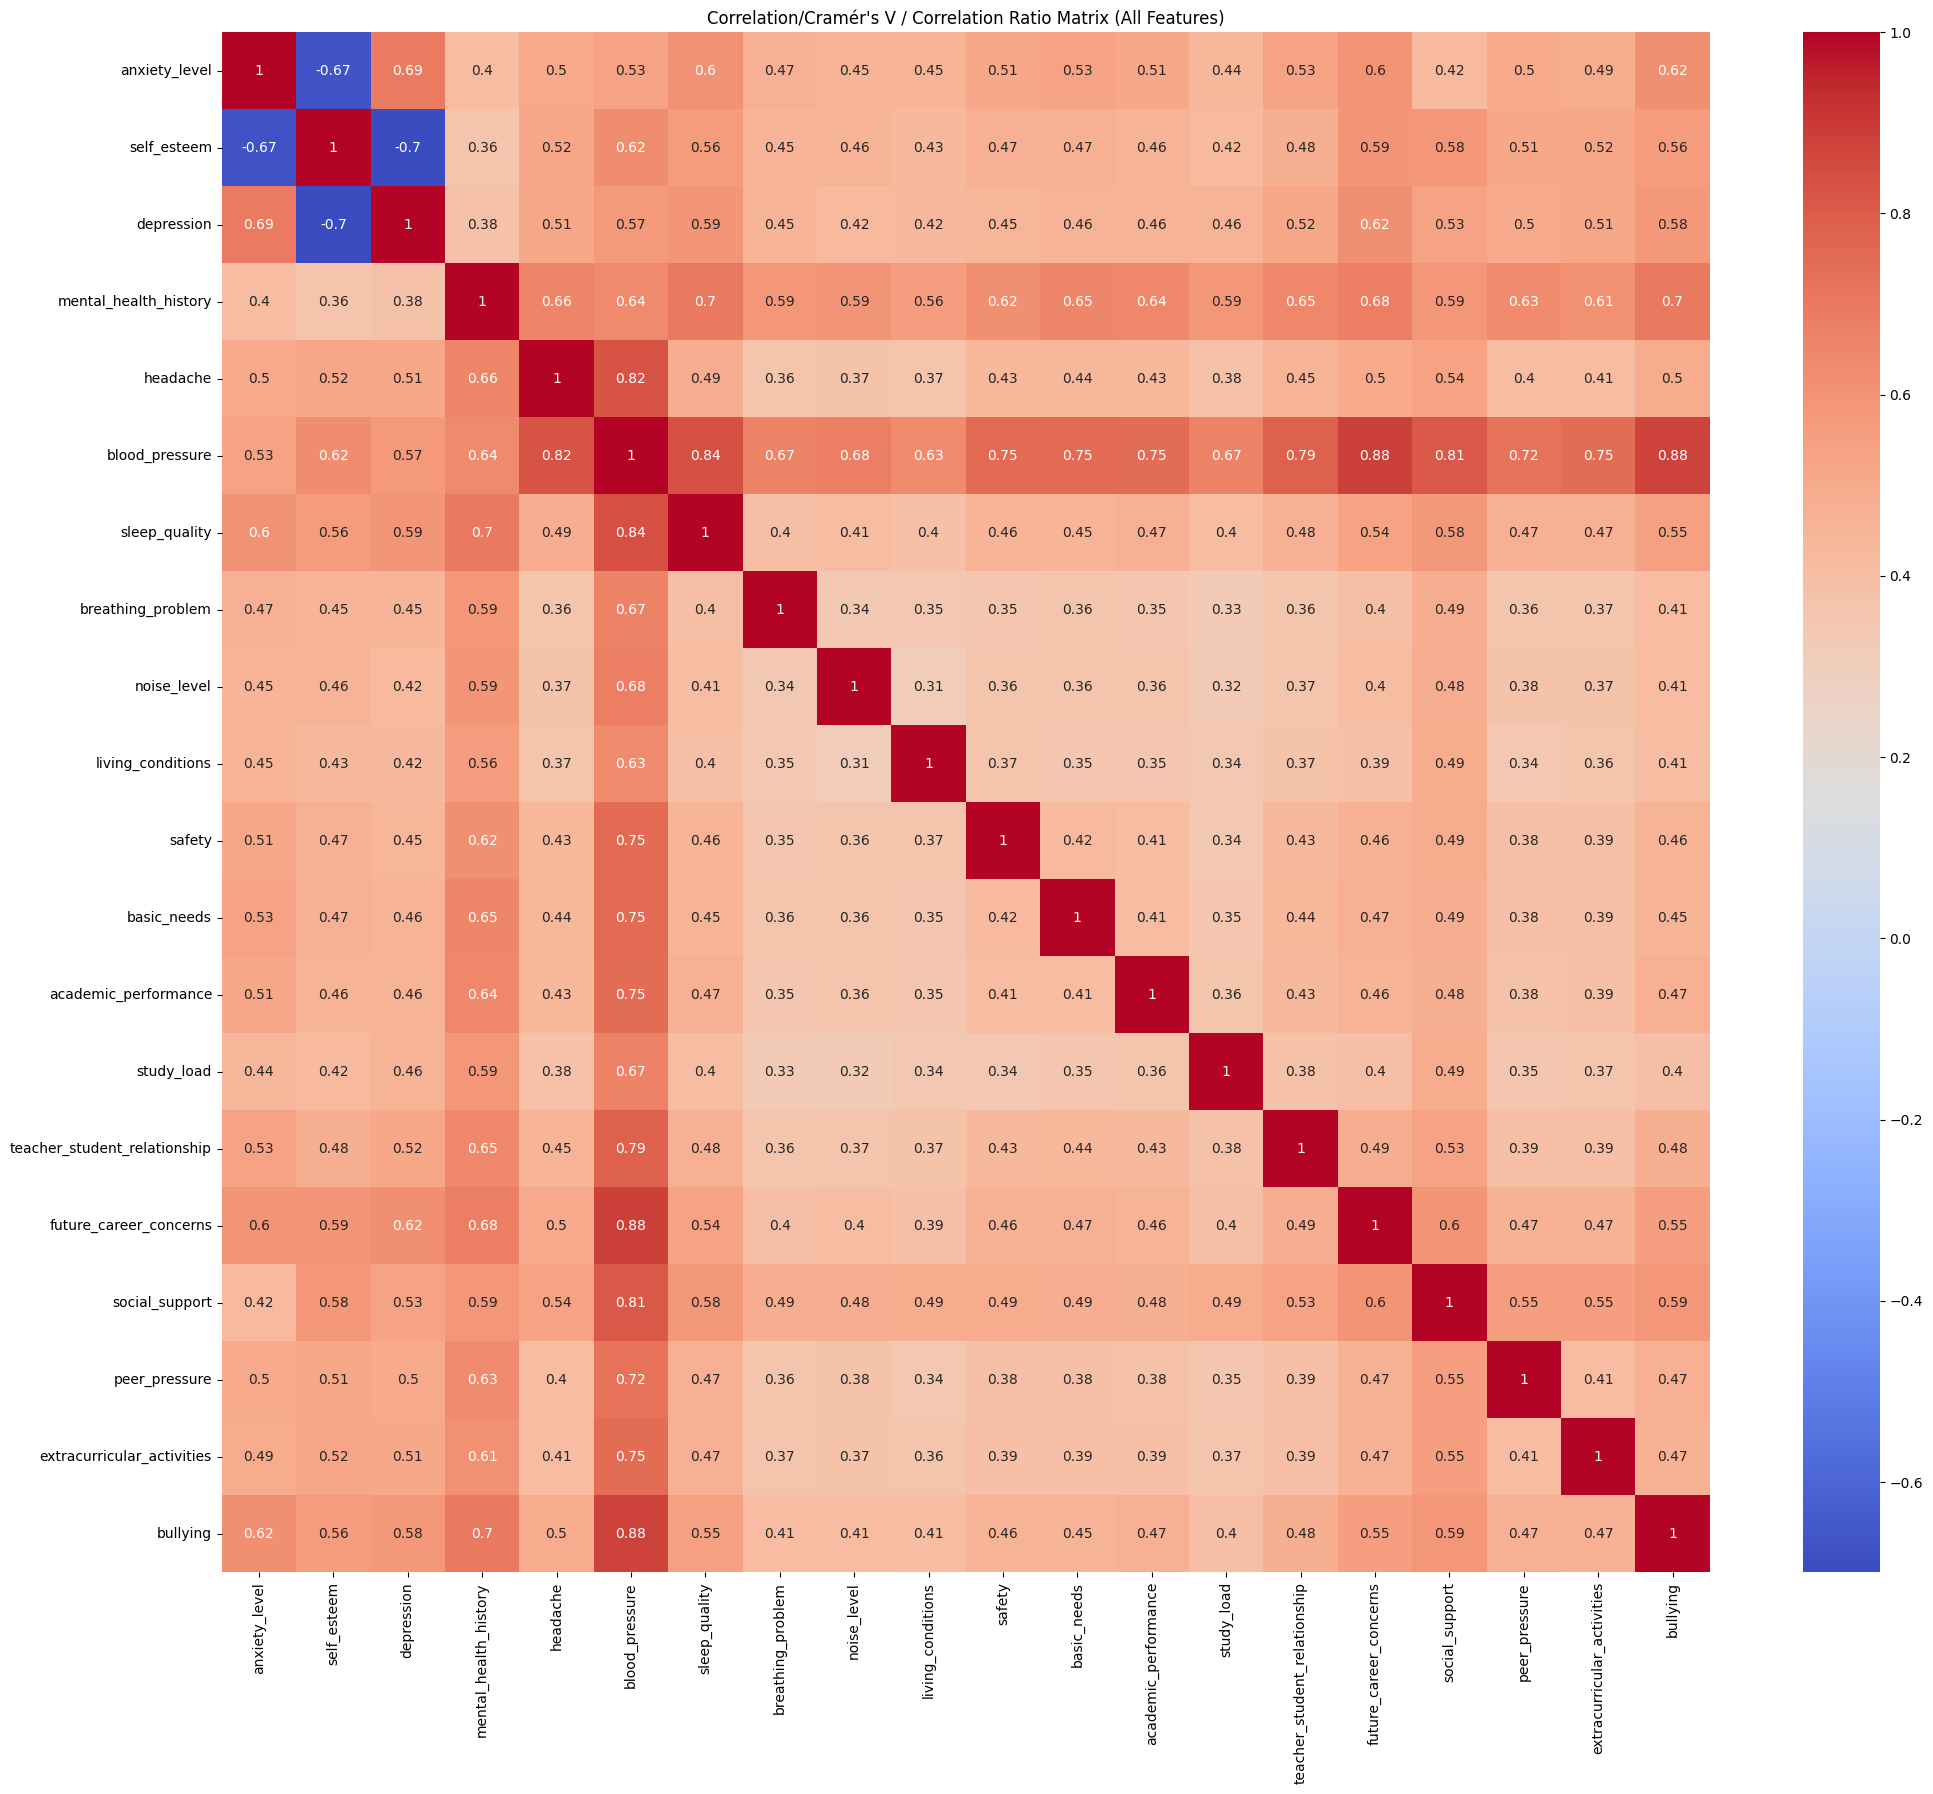


Chi-square test results:
                                      chi2 p_value significant
bullying                      1499.115306     0.0        True
blood_pressure                1570.409933     0.0        True
sleep_quality                  1520.26979     0.0        True
future_career_concerns        1522.275033     0.0        True
headache                      1253.627107     0.0        True
academic_performance          1144.743968     0.0        True
extracurricular_activities    1129.058982     0.0        True
teacher_student_relationship  1122.306648     0.0        True
basic_needs                   1119.877389     0.0        True
safety                        1092.030971     0.0        True
peer_pressure                 1074.753892     0.0        True
social_support                1040.588102     0.0        True
noise_level                    866.765408     0.0        True
study_load                     797.200769     0.0        True
living_conditions              782.585661  

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import f_classif
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")
target = 'stress_level'

# ---------------------------
# 2. Identify categorical vs numerical
# ---------------------------
categorical_cols = [col for col in df.columns if df[col].nunique() <= 10 and col != target]
numerical_cols = [col for col in df.columns if col not in categorical_cols and col != target]

# ---------------------------
# 3. Correlation / Association matrix
# ---------------------------
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape)-1
    return np.sqrt(chi2 / (n * min_dim))

all_cols = numerical_cols + categorical_cols
corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for i in all_cols:
    for j in all_cols:
        if i in numerical_cols and j in numerical_cols:
            corr_matrix.loc[i,j] = df[i].corr(df[j])  # Pearson
        elif i in categorical_cols and j in categorical_cols:
            corr_matrix.loc[i,j] = cramers_v(df[i], df[j])  # Cramer's V
        else:
            # Numerical vs Categorical: Correlation ratio (η²)
            if i in numerical_cols:
                num, cat = i, j
            else:
                num, cat = j, i
            categories = df[cat].unique()
            grand_mean = df[num].mean()
            ss_between = sum(df[num][df[cat]==c].count() * (df[num][df[cat]==c].mean() - grand_mean)**2 for c in categories)
            ss_total = sum((df[num] - grand_mean)**2)
            corr_matrix.loc[i,j] = ss_between / ss_total

plt.figure(figsize=(len(all_cols)*1.2, len(all_cols)*1))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm')
plt.title("Correlation/Cramér's V / Correlation Ratio Matrix (All Features)")
plt.show()

# ---------------------------
# 4. Chi-Square test for categorical features vs target
# ---------------------------
chi2_results = {}
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    chi2_results[col] = {'chi2': chi2, 'p_value': p, 'significant': p < 0.05}

chi2_df = pd.DataFrame(chi2_results).T.sort_values('p_value')
print("\nChi-square test results:\n", chi2_df)

# Select significant categorical features
significant_categorical = chi2_df[chi2_df['significant']].index.tolist()
print("Significant categorical features:", significant_categorical)

# ---------------------------
# 5. ANOVA F-test for numerical features vs target
# ---------------------------
if numerical_cols:
    F_values, p_values = f_classif(df[numerical_cols], df[target])
    anova_results = pd.DataFrame({
        'Feature': numerical_cols,
        'F_value': F_values,
        'p_value': p_values,
        'significant': p_values < 0.05
    }).sort_values('p_value')
    print("\nANOVA F-test results:\n", anova_results)

    # Select significant numerical features
    significant_numerical = anova_results[anova_results['significant']]['Feature'].tolist()
    print("Significant numerical features:", significant_numerical)
else:
    significant_numerical = []
    print("\nNo numerical columns for ANOVA F-test.")

# ---------------------------
# 6. Combine selected features
# ---------------------------
selected_features = significant_numerical + significant_categorical
print("\nAll selected significant features:", selected_features)


Categorical features: ['mental_health_history', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']
Numerical features: ['anxiety_level', 'self_esteem', 'depression']


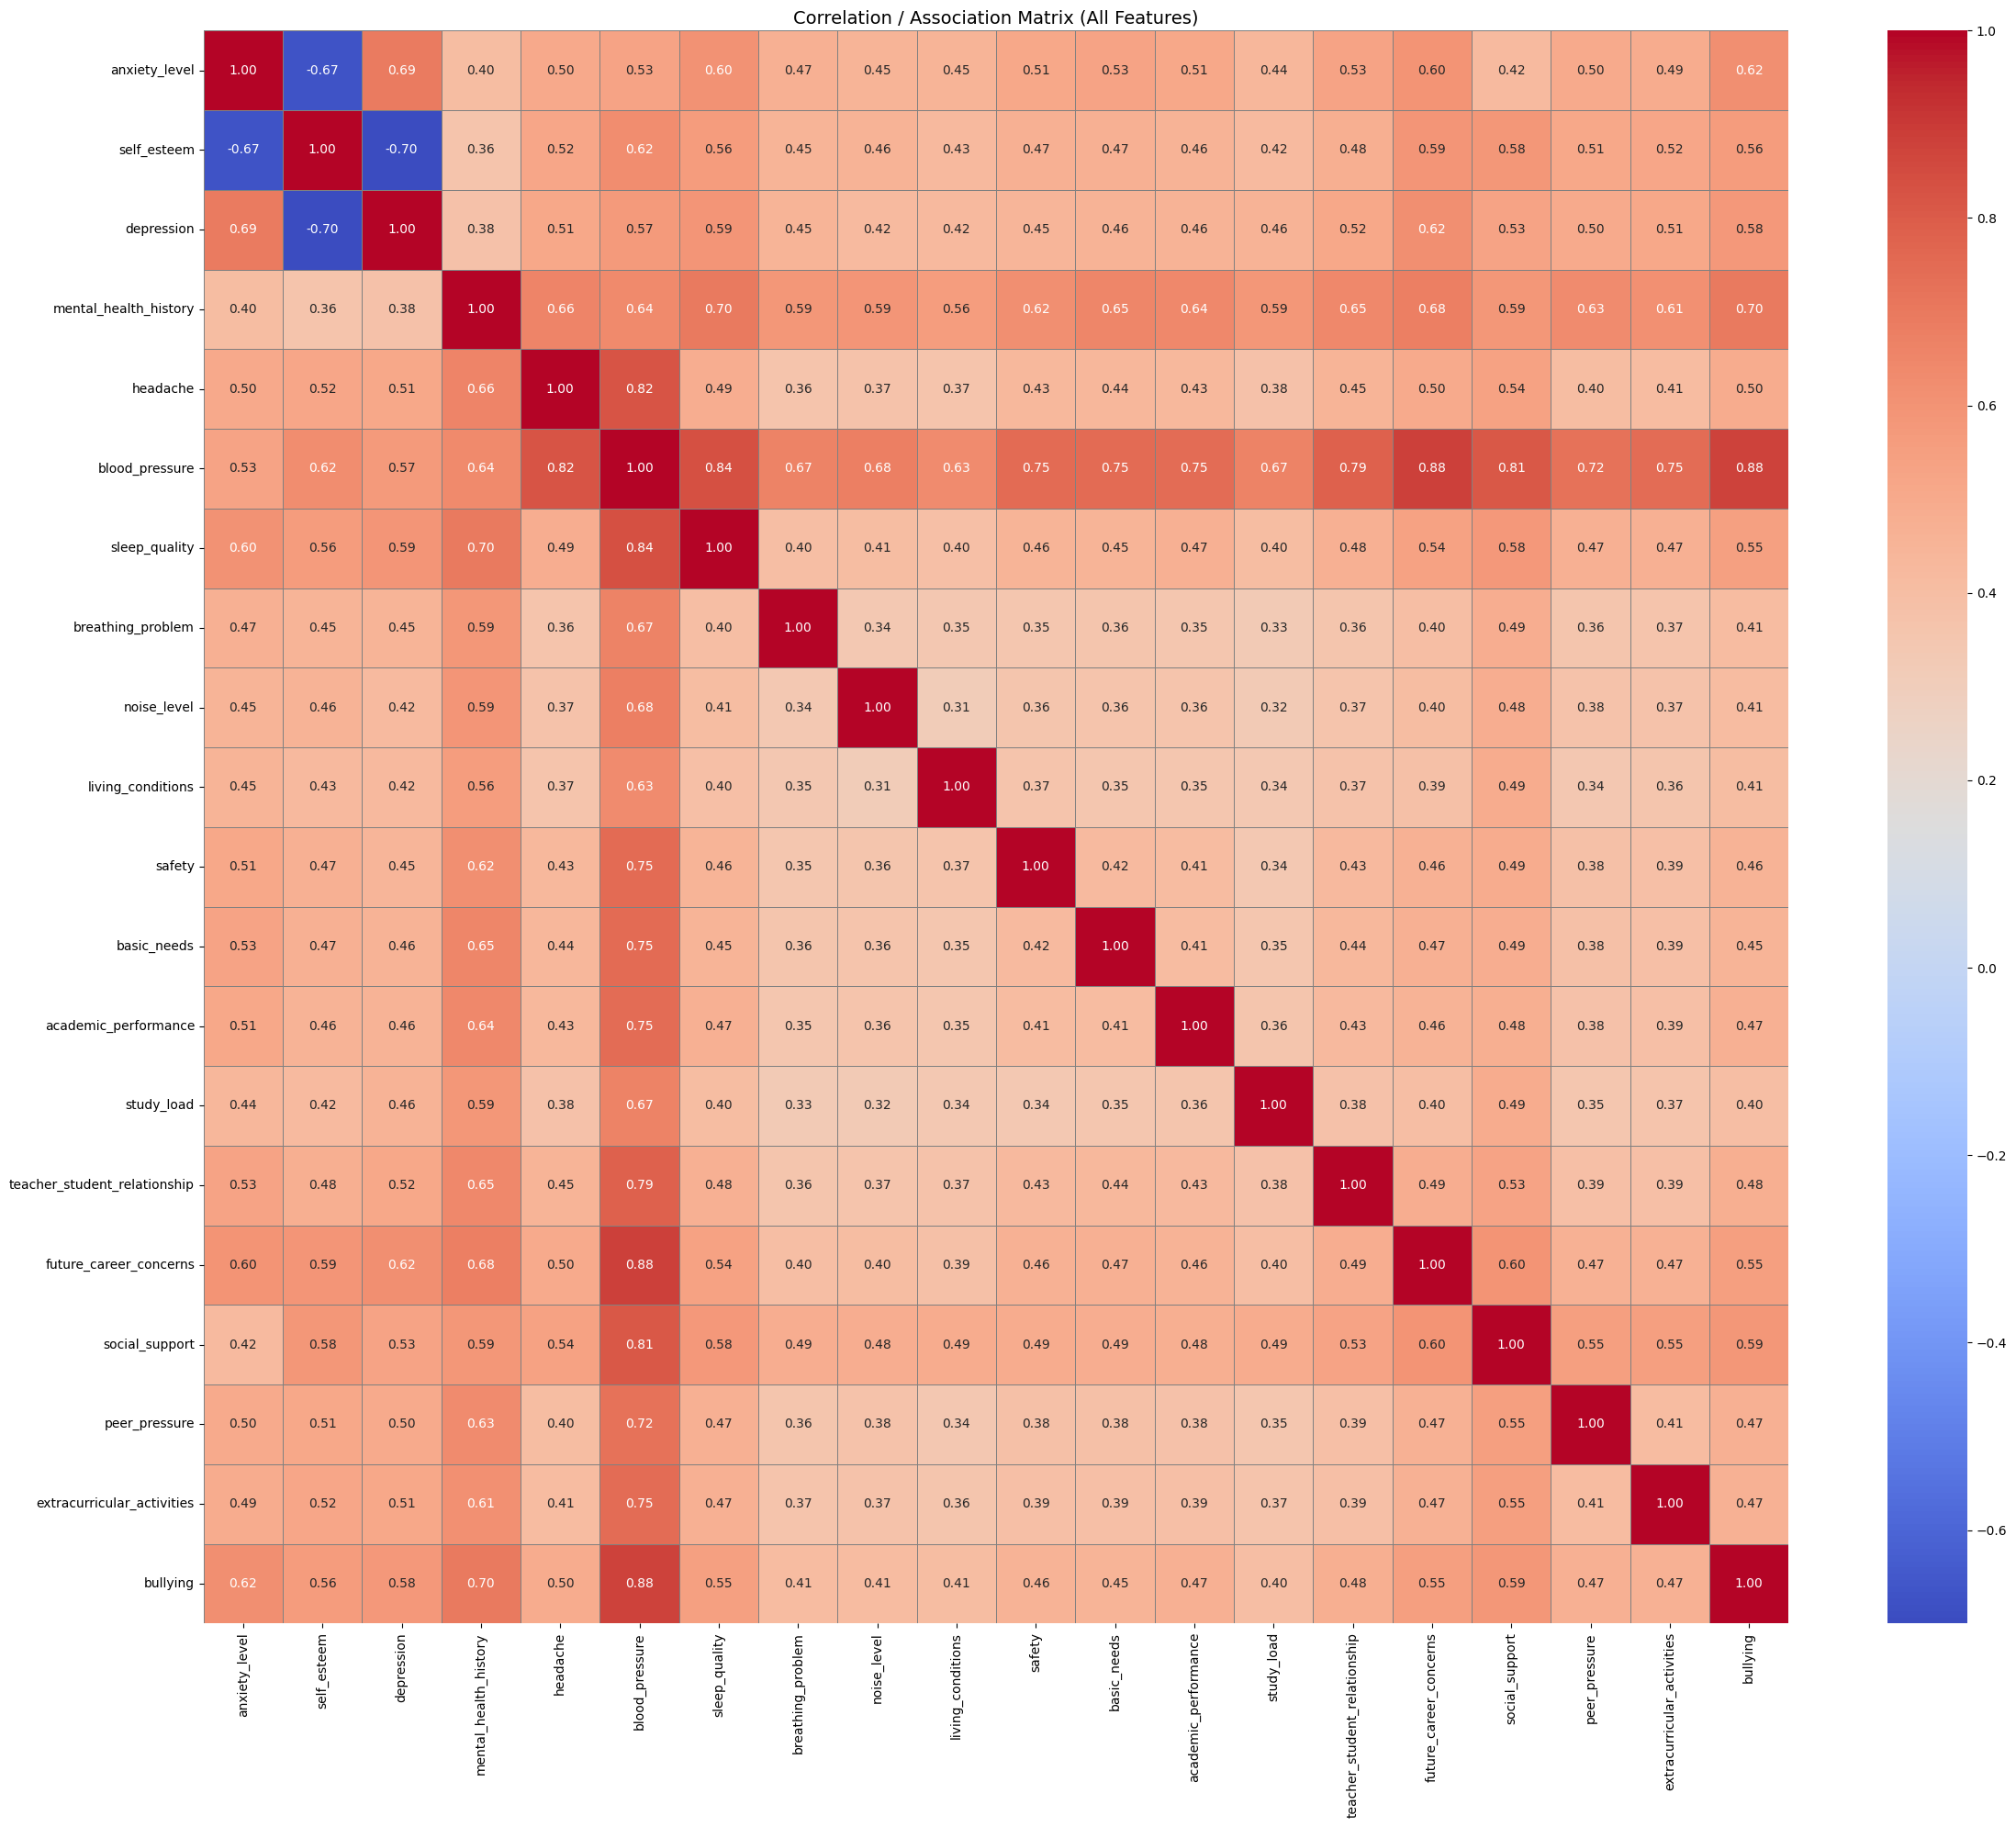


Chi-square test results:
                                      chi2 p_value significant
bullying                      1499.115306     0.0        True
blood_pressure                1570.409933     0.0        True
sleep_quality                  1520.26979     0.0        True
future_career_concerns        1522.275033     0.0        True
headache                      1253.627107     0.0        True
academic_performance          1144.743968     0.0        True
extracurricular_activities    1129.058982     0.0        True
teacher_student_relationship  1122.306648     0.0        True
basic_needs                   1119.877389     0.0        True
safety                        1092.030971     0.0        True
peer_pressure                 1074.753892     0.0        True
social_support                1040.588102     0.0        True
noise_level                    866.765408     0.0        True
study_load                     797.200769     0.0        True
living_conditions              782.585661  

In [18]:
# ==============================
# Hybrid Correlation + Feature Selection (Stress Dataset)
# ==============================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import f_classif
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")
target = 'stress_level'

# ---------------------------
# 2. Identify categorical vs numerical
# ---------------------------
categorical_cols = [col for col in df.columns if df[col].nunique() <= 10 and col != target]
numerical_cols = [col for col in df.columns if col not in categorical_cols and col != target]

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

# ---------------------------
# 3. Association / Correlation Matrix
# ---------------------------
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

all_cols = numerical_cols + categorical_cols
corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for i in all_cols:
    for j in all_cols:
        if i in numerical_cols and j in numerical_cols:
            corr_matrix.loc[i, j] = df[i].corr(df[j])  # Pearson
        elif i in categorical_cols and j in categorical_cols:
            corr_matrix.loc[i, j] = cramers_v(df[i], df[j])  # Cramér's V
        else:
            # Numerical vs Categorical → correlation ratio (η²)
            if i in numerical_cols:
                num, cat = i, j
            else:
                num, cat = j, i
            categories = df[cat].unique()
            grand_mean = df[num].mean()
            ss_between = sum(
                df[num][df[cat] == c].count() *
                (df[num][df[cat] == c].mean() - grand_mean) ** 2
                for c in categories
            )
            ss_total = sum((df[num] - grand_mean) ** 2)
            corr_matrix.loc[i, j] = ss_between / ss_total

# ---------------------------
# 4. Plot heatmap (all features)
# ---------------------------
plt.figure(figsize=(len(all_cols)*1.2, len(all_cols)))
sns.heatmap(
    corr_matrix.astype(float),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    linecolor="gray"
)
plt.title("Correlation / Association Matrix (All Features)", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------
# 5. Chi-Square test (categorical vs target)
# ---------------------------
chi2_results = {}
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    chi2_results[col] = {'chi2': chi2, 'p_value': p, 'significant': p < 0.05}

chi2_df = pd.DataFrame(chi2_results).T.sort_values('p_value')
print("\nChi-square test results:\n", chi2_df)

# ---------------------------
# 6. ANOVA F-test (numerical vs target)
# ---------------------------
if numerical_cols:
    F_values, p_values = f_classif(df[numerical_cols], df[target])
    anova_results = pd.DataFrame({
        'Feature': numerical_cols,
        'F_value': F_values,
        'p_value': p_values,
        'significant': p_values < 0.05
    }).sort_values('p_value')
    print("\nANOVA F-test results:\n", anova_results)

    significant_numerical = anova_results[anova_results['significant']]['Feature'].tolist()
else:
    significant_numerical = []
    print("\nNo numerical columns for ANOVA F-test.")

# ---------------------------
# 7. Combine selected features
# ---------------------------
significant_categorical = chi2_df[chi2_df['significant']].index.tolist()
selected_features = significant_numerical + significant_categorical

print("\nSelected Features for Model:", selected_features)


Categorical features: ['mental_health_history', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']
Numerical features: ['anxiety_level', 'self_esteem', 'depression']


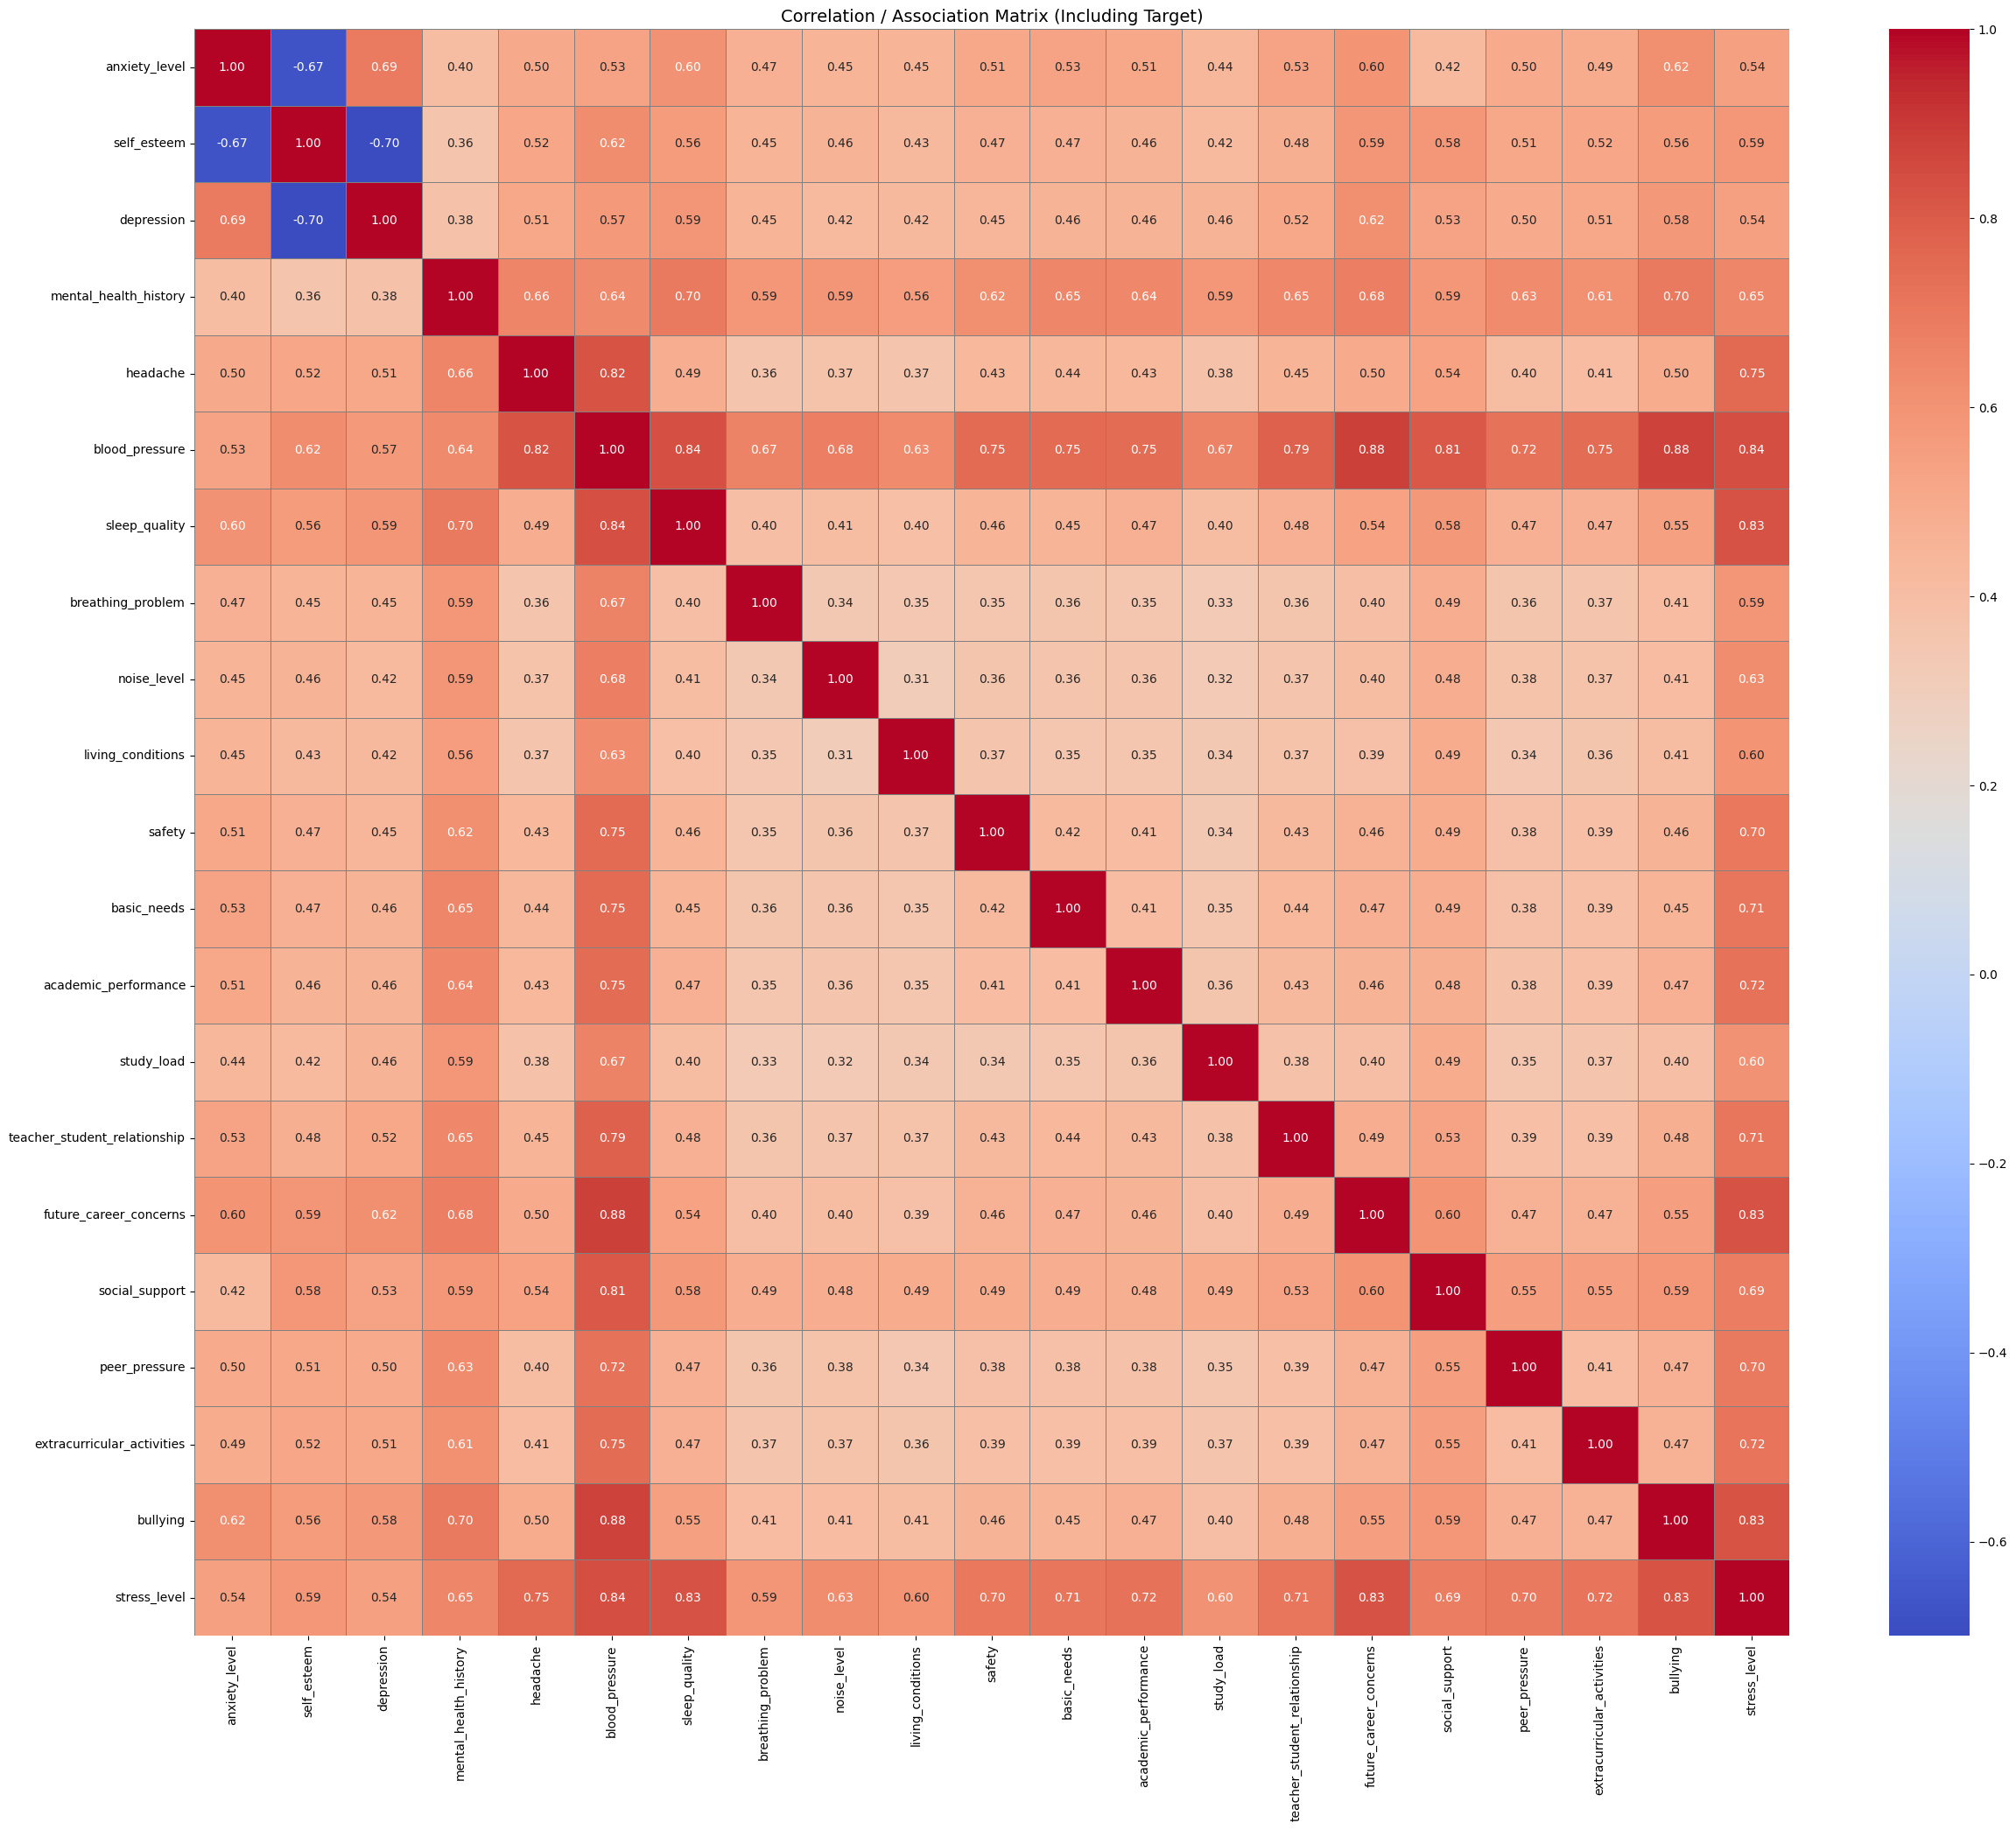


Chi-square test results:
                                      chi2 p_value significant
bullying                      1499.115306     0.0        True
blood_pressure                1570.409933     0.0        True
sleep_quality                  1520.26979     0.0        True
future_career_concerns        1522.275033     0.0        True
headache                      1253.627107     0.0        True
academic_performance          1144.743968     0.0        True
extracurricular_activities    1129.058982     0.0        True
teacher_student_relationship  1122.306648     0.0        True
basic_needs                   1119.877389     0.0        True
safety                        1092.030971     0.0        True
peer_pressure                 1074.753892     0.0        True
social_support                1040.588102     0.0        True
noise_level                    866.765408     0.0        True
study_load                     797.200769     0.0        True
living_conditions              782.585661  

/tmp/ipython-input-20157556.py:153: RuntimeWarning: divide by zero encountered in scalar divide
  cat_corr_target = {col: 1/chi2_df.loc[col, 'p_value'] for col in significant_categorical}


In [19]:
# ==============================
# Hybrid Correlation + Feature Selection (Stress Dataset)
# ==============================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import f_classif
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")
target = 'stress_level'

# ---------------------------
# 2. Identify categorical vs numerical
# ---------------------------
categorical_cols = [col for col in df.columns if df[col].nunique() <= 10 and col != target]
numerical_cols = [col for col in df.columns if col not in categorical_cols and col != target]

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

# ---------------------------
# 3. Correlation / Association Matrix (including target)
# ---------------------------
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

# Include target in correlation matrix
all_cols = numerical_cols + categorical_cols + [target]
corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for i in all_cols:
    for j in all_cols:
        if i in numerical_cols and j in numerical_cols:
            corr_matrix.loc[i, j] = df[i].corr(df[j])  # Pearson
        elif i in categorical_cols and j in categorical_cols:
            corr_matrix.loc[i, j] = cramers_v(df[i], df[j])  # Cramér's V
        elif i == target or j == target:
            # Numerical vs target (categorical) → correlation ratio (η²)
            if i in numerical_cols:
                num, cat = i, target
            elif j in numerical_cols:
                num, cat = j, target
            else:
                # target vs categorical → Cramer's V
                corr_matrix.loc[i, j] = cramers_v(df[i], df[j])
                continue
            categories = df[cat].unique()
            grand_mean = df[num].mean()
            ss_between = sum(
                df[num][df[cat] == c].count() *
                (df[num][df[cat] == c].mean() - grand_mean) ** 2
                for c in categories
            )
            ss_total = sum((df[num] - grand_mean) ** 2)
            corr_matrix.loc[i, j] = ss_between / ss_total
        else:
            # Numerical vs Categorical → correlation ratio (η²)
            if i in numerical_cols:
                num, cat = i, j
            else:
                num, cat = j, i
            categories = df[cat].unique()
            grand_mean = df[num].mean()
            ss_between = sum(
                df[num][df[cat] == c].count() *
                (df[num][df[cat] == c].mean() - grand_mean) ** 2
                for c in categories
            )
            ss_total = sum((df[num] - grand_mean) ** 2)
            corr_matrix.loc[i, j] = ss_between / ss_total

# ---------------------------
# 4. Plot heatmap
# ---------------------------
plt.figure(figsize=(len(all_cols)*1.2, len(all_cols)))
sns.heatmap(
    corr_matrix.astype(float),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    linecolor="gray"
)
plt.title("Correlation / Association Matrix (Including Target)", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------
# 5. Chi-Square test (categorical vs target)
# ---------------------------
chi2_results = {}
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    chi2_results[col] = {'chi2': chi2, 'p_value': p, 'significant': p < 0.05}

chi2_df = pd.DataFrame(chi2_results).T.sort_values('p_value')
print("\nChi-square test results:\n", chi2_df)

# ---------------------------
# 6. ANOVA F-test (numerical vs target)
# ---------------------------
if numerical_cols:
    F_values, p_values = f_classif(df[numerical_cols], df[target])
    anova_results = pd.DataFrame({
        'Feature': numerical_cols,
        'F_value': F_values,
        'p_value': p_values,
        'significant': p_values < 0.05
    }).sort_values('p_value')
    print("\nANOVA F-test results:\n", anova_results)

    significant_numerical = anova_results[anova_results['significant']]['Feature'].tolist()
else:
    significant_numerical = []
    print("\nNo numerical columns for ANOVA F-test.")

# ---------------------------
# 7. Combine selected features (top predictors)
# ---------------------------
significant_categorical = chi2_df[chi2_df['significant']].index.tolist()
selected_features = significant_numerical + significant_categorical

print("\nSelected Features for Model:", selected_features)

# ---------------------------
# 8. Show top correlated features with target
# ---------------------------
# For numerical features: correlation ratio with target
num_corr_target = {}
for col in numerical_cols:
    categories = df[target].unique()
    grand_mean = df[col].mean()
    ss_between = sum(
        df[col][df[target] == c].count() *
        (df[col][df[target] == c].mean() - grand_mean) ** 2
        for c in categories
    )
    ss_total = sum((df[col] - grand_mean) ** 2)
    num_corr_target[col] = ss_between / ss_total

# For categorical features: use chi2 p-value (smaller p → stronger)
cat_corr_target = {col: 1/chi2_df.loc[col, 'p_value'] for col in significant_categorical}

# Combine and sort
all_corr_target = {**num_corr_target, **cat_corr_target}
top_features = sorted(all_corr_target.items(), key=lambda x: x[1], reverse=True)
print("\nTop Features Correlated with Target:\n", top_features[:10])


Categorical features: ['mental_health_history', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']
Numerical features: ['anxiety_level', 'self_esteem', 'depression']

Feature–Target Associations:
                               Association_with_StressLevel
blood_pressure                                    0.844880
future_career_concerns                            0.831831
sleep_quality                                     0.831283
bullying                                          0.825479
headache                                          0.754871
academic_performance                              0.721345
extracurricular_activities                        0.716386
teacher_student_relationship                      0.714240
basic_needs          

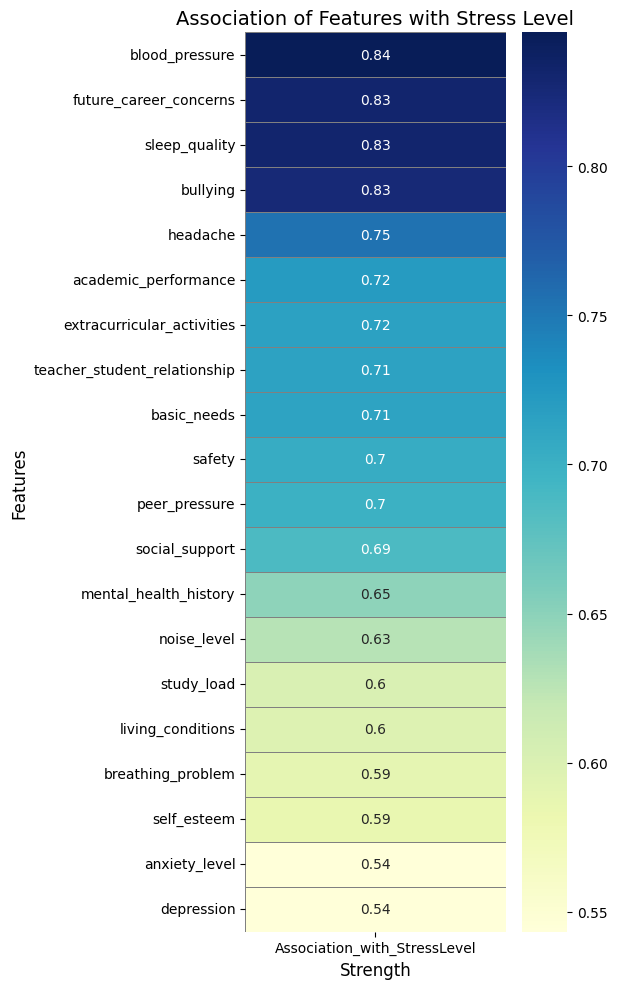

In [20]:
# ==============================
# Feature–Target Association Analysis (Stress Level)
# ==============================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1. Load dataset
# ---------------------------
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")
target = "stress_level"

# ---------------------------
# 2. Identify categorical vs numerical features
# ---------------------------
categorical_cols = [col for col in df.columns if df[col].nunique() <= 10 and col != target]
numerical_cols = [col for col in df.columns if col not in categorical_cols and col != target]

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

# ---------------------------
# 3. Helper: Cramér's V for categorical–categorical
# ---------------------------
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

# ---------------------------
# 4. Correlation/Association with target only
# ---------------------------
feature_target_corr = {}

for col in df.columns:
    if col == target:
        continue

    if col in numerical_cols:
        # Correlation ratio (η²)
        categories = df[target].unique()
        grand_mean = df[col].mean()
        ss_between = sum(
            df[col][df[target] == c].count() *
            (df[col][df[target] == c].mean() - grand_mean) ** 2
            for c in categories
        )
        ss_total = sum((df[col] - grand_mean) ** 2)
        eta_squared = ss_between / ss_total
        feature_target_corr[col] = eta_squared

    elif col in categorical_cols:
        # Cramér's V
        feature_target_corr[col] = cramers_v(df[col], df[target])

# ---------------------------
# 5. Convert to DataFrame
# ---------------------------
target_corr_df = pd.DataFrame.from_dict(
    feature_target_corr, orient='index',
    columns=['Association_with_StressLevel']
).sort_values('Association_with_StressLevel', ascending=False)

print("\nFeature–Target Associations:\n", target_corr_df)

# ---------------------------
# 6. Plot heatmap
# ---------------------------
plt.figure(figsize=(6, len(target_corr_df) * 0.5))
sns.heatmap(
    target_corr_df, annot=True, cmap="YlGnBu",
    cbar=True, linewidths=0.5, linecolor="gray"
)
plt.title("Association of Features with Stress Level", fontsize=14)
plt.xlabel("Strength", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.feature_selection import f_classif

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")
target = 'stress_level'

# Identify categorical vs numerical
categorical_cols = [col for col in df.columns if df[col].nunique() <= 10 and col != target]
numerical_cols = [col for col in df.columns if col not in categorical_cols and col != target]

# Function to compute Cramér's V for categorical vs categorical
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape)-1
    return np.sqrt(chi2 / (n * min_dim))

# Correlation/association matrix for all features
all_cols = numerical_cols + categorical_cols
corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for i in all_cols:
    for j in all_cols:
        if i in numerical_cols and j in numerical_cols:
            corr_matrix.loc[i,j] = df[i].corr(df[j])  # Pearson
        elif i in categorical_cols and j in categorical_cols:
            corr_matrix.loc[i,j] = cramers_v(df[i], df[j])  # Cramer's V
        else:
            # Numerical vs Categorical: Correlation ratio (η²)
            if i in numerical_cols:
                num, cat = i, j
            else:
                num, cat = j, i
            categories = df[cat].unique()
            grand_mean = df[num].mean()
            ss_between = sum(df[num][df[cat]==c].count() * (df[num][df[cat]==c].mean() - grand_mean)**2 for c in categories)
            ss_total = sum((df[num] - grand_mean)**2)
            corr_matrix.loc[i,j] = ss_between / ss_total

# ---------------------------
# Print the correlation/association matrix
# ---------------------------
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print("Correlation/Association matrix (All features):\n")
print(corr_matrix)


Correlation/Association matrix (All features):

                              anxiety_level  self_esteem  depression  \
anxiety_level                      1.000000    -0.672745    0.694340   
self_esteem                       -0.672745     1.000000   -0.699602   
depression                         0.694340    -0.699602    1.000000   
mental_health_history              0.402526     0.364215    0.379311   
headache                           0.504813     0.515446    0.510626   
blood_pressure                     0.531953     0.622196    0.572019   
sleep_quality                      0.604804     0.563327    0.589088   
breathing_problem                  0.470882     0.450034    0.450512   
noise_level                        0.451805     0.457359    0.419353   
living_conditions                  0.451670     0.427946    0.424536   
safety                             0.514262     0.471858    0.448722   
basic_needs                        0.532271     0.470286    0.459823   
academic_perform

In [22]:
# List of all significant features
selected_features = ['self_esteem', 'anxiety_level', 'depression',
                     'bullying', 'blood_pressure', 'sleep_quality',
                     'future_career_concerns', 'headache', 'academic_performance',
                     'extracurricular_activities', 'teacher_student_relationship',
                     'basic_needs', 'safety', 'peer_pressure', 'social_support',
                     'noise_level', 'study_load', 'living_conditions',
                     'breathing_problem', 'mental_health_history']

# Create new dataset with only significant features + target
df_selected = df[selected_features + [target]]

# Display first 5 rows
print(df_selected.head())


   self_esteem  anxiety_level  depression  bullying  blood_pressure  \
0           20             14          11         2               1   
1            8             15          15         5               3   
2           18             12          14         2               1   
3           12             16          15         5               3   
4           28             16           7         5               3   

   sleep_quality  future_career_concerns  headache  academic_performance  \
0              2                       3         2                     3   
1              1                       5         5                     1   
2              2                       2         2                     2   
3              1                       4         4                     2   
4              5                       2         2                     4   

   extracurricular_activities  teacher_student_relationship  basic_needs  \
0                           3           

In [23]:
# ---------------------------
# Stricter thresholds
# ---------------------------

# For numerical features (ANOVA F-test)
anova_threshold = 500
significant_numerical_strict = anova_results[anova_results['F_value'] > anova_threshold]['Feature'].tolist()
print("Significant numerical features (strict):", significant_numerical_strict)

# For categorical features (Chi-square test)
chi2_threshold = 1000
significant_categorical_strict = chi2_df[chi2_df['chi2'] > chi2_threshold].index.tolist()
print("Significant categorical features (strict):", significant_categorical_strict)

# Combine strict features
selected_features_strict = significant_numerical_strict + significant_categorical_strict
print("All selected significant features (strict):", selected_features_strict)

# Create new dataset with only strict features + target
df_selected_strict = df[selected_features_strict + [target]]
print(df_selected_strict.head())


Significant numerical features (strict): ['self_esteem', 'anxiety_level', 'depression']
Significant categorical features (strict): ['bullying', 'blood_pressure', 'sleep_quality', 'future_career_concerns', 'headache', 'academic_performance', 'extracurricular_activities', 'teacher_student_relationship', 'basic_needs', 'safety', 'peer_pressure', 'social_support']
All selected significant features (strict): ['self_esteem', 'anxiety_level', 'depression', 'bullying', 'blood_pressure', 'sleep_quality', 'future_career_concerns', 'headache', 'academic_performance', 'extracurricular_activities', 'teacher_student_relationship', 'basic_needs', 'safety', 'peer_pressure', 'social_support']
   self_esteem  anxiety_level  depression  bullying  blood_pressure  \
0           20             14          11         2               1   
1            8             15          15         5               3   
2           18             12          14         2               1   
3           12             16  

In [24]:
# Separate features and target
X = df_selected_strict.drop(columns=[target])
y = df_selected_strict[target]

# Optional: Encode categorical features if using models that require numerical input
from sklearn.preprocessing import OrdinalEncoder

categorical_cols_strict = ['bullying', 'blood_pressure', 'sleep_quality',
                           'future_career_concerns', 'headache', 'academic_performance',
                           'extracurricular_activities', 'teacher_student_relationship',
                           'basic_needs', 'safety', 'peer_pressure', 'social_support']

encoder = OrdinalEncoder()
X[categorical_cols_strict] = encoder.fit_transform(X[categorical_cols_strict])

# Check prepared dataset
print(X.head())
print(y.value_counts())


   self_esteem  anxiety_level  depression  bullying  blood_pressure  \
0           20             14          11       2.0             0.0   
1            8             15          15       5.0             2.0   
2           18             12          14       2.0             0.0   
3           12             16          15       5.0             2.0   
4           28             16           7       5.0             2.0   

   sleep_quality  future_career_concerns  headache  academic_performance  \
0            2.0                     3.0       2.0                   3.0   
1            1.0                     5.0       5.0                   1.0   
2            2.0                     2.0       2.0                   2.0   
3            1.0                     4.0       4.0                   2.0   
4            5.0                     2.0       2.0                   4.0   

   extracurricular_activities  teacher_student_relationship  basic_needs  \
0                         3.0           

In [25]:
pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.4 MB/s eta 0:00:00


In [26]:
!pip install ctgan


In [27]:
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [28]:
!pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 48.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [sdv]


In [29]:
!pip install --upgrade pip
!pip install "sdv>=1.24.0"


In [30]:
!pip install ctgan


In [31]:
!pip uninstall ctgan -y

Found existing installation: ctgan 0.11.0
Uninstalling ctgan-0.11.0:
  Successfully uninstalled ctgan-0.11.0


In [32]:
!pip install git+https://github.com/sdv-dev/CTGAN.git

  Cloning https://github.com/sdv-dev/CTGAN.git to /tmp/pip-req-build-d9wpyvhi
  Running command git clone --filter=blob:none --quiet https://github.com/sdv-dev/CTGAN.git /tmp/pip-req-build-d9wpyvhi
  Resolved https://github.com/sdv-dev/CTGAN.git to commit ccd23ca8e755b5aa17de755b846829a066f8ad62
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ctgan: filename=ctgan-0.11.1.dev0-py3-none-any.whl size=24483 sha256=2874bb0d6d4204b1411ab181e47360f240523b18e9249f4b935bed886e6164d5
  Stored in directory: /tmp/pip-ephem-wheel-cache-6rrnk1rs/wheels/36/89/ba/deb56ec90bfeb595e97b07b759ff297d65b9fe792607a5625a
Successfully built ctgan


In [33]:
!pip install "sdv>=1.16.0"


In [34]:
!python --version


Python 3.12.11


In [35]:
!pip install sdv


In [36]:
# ==============================
# Stress Prediction with CTGAN + ML Models
# ==============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# SDV (CTGAN)
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ==============================
# 1. Load Dataset
# ==============================
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

target = 'stress_level'
selected_features = [
    'self_esteem', 'anxiety_level', 'depression', 'bullying',
    'blood_pressure', 'sleep_quality', 'future_career_concerns',
    'headache', 'academic_performance', 'extracurricular_activities',
    'teacher_student_relationship', 'basic_needs', 'safety',
    'peer_pressure', 'social_support'
]

df = df[selected_features + [target]]

# ==============================
# 2. Train/Test Split
# ==============================
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df[target] = y_train

# ==============================
# 3. Metadata for CTGAN
# ==============================
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_df)

# Explicitly set categorical columns
categorical_cols = [
    'bullying', 'blood_pressure', 'sleep_quality',
    'future_career_concerns', 'headache', 'academic_performance',
    'extracurricular_activities', 'teacher_student_relationship',
    'basic_needs', 'safety', 'peer_pressure', 'social_support'
]

for col in categorical_cols:
    metadata.update_column(col, sdtype="categorical")

metadata.update_column(target, sdtype="categorical")

# ==============================
# 4. Train CTGAN
# ==============================
synthesizer = CTGANSynthesizer(
    metadata,
    epochs=300,              # increase if dataset is small
    batch_size=128,
    generator_dim=(128, 128),
    discriminator_dim=(128, 128),
    pac=1                    # ✅ avoids AssertionError
)

print("Training CTGAN...")
synthesizer.fit(train_df)
print("CTGAN training complete.")

# ==============================
# 5. Generate Synthetic Data
# ==============================
synthetic_data = synthesizer.sample(num_rows=len(train_df))

# Combine real + synthetic for training
train_df_aug = pd.concat([train_df, synthetic_data], axis=0).sample(frac=1, random_state=42)

X_train_aug = train_df_aug.drop(columns=[target])
y_train_aug = train_df_aug[target]

# ==============================
# 6. Preprocessing (OneHot + Scaling)
# ==============================
numerical_cols = ['self_esteem', 'anxiety_level', 'depression']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_aug_enc = preprocessor.fit_transform(X_train_aug)
X_test_enc = preprocessor.transform(X_test)

# ==============================
# 7. Define Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=5),
    "SVM": SVC(probability=True, class_weight="balanced"),
    "MLP Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True)
}

# ==============================
# 8. Train & Evaluate
# ==============================
results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_aug_enc, y_train_aug)
    y_pred = model.predict(X_test_enc)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

# ==============================
# 9. Results
# ==============================
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\nFinal Results:")
print(results_df)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Training CTGAN...
CTGAN training complete.
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training MLP Neural Network...

Final Results:
                 Model  Accuracy  Precision    Recall  F1-score
1        Random Forest  0.904545   0.906022  0.904545  0.904474
3                  SVM  0.904545   0.909044  0.904545  0.904701
0  Logistic Regression  0.890909   0.892682  0.890909  0.890689
4   MLP Neural Network  0.881818   0.883445  0.881818  0.881884
2    Gradient Boosting  0.877273   0.879298  0.877273  0.877315


In [37]:
# ==============================
# Stress Prediction with CTGAN + ML Models (Updated)
# ==============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# SDV (CTGAN)
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ==============================
# 1. Load Dataset
# ==============================
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")
target = 'stress_level'

# ------------------------------
# Selected features from correlation / feature selection
# ------------------------------
selected_features = [
    'self_esteem', 'anxiety_level', 'depression', 'bullying',
    'blood_pressure', 'sleep_quality', 'future_career_concerns',
    'headache', 'academic_performance', 'extracurricular_activities',
    'teacher_student_relationship', 'basic_needs', 'safety',
    'peer_pressure', 'social_support'
]

df = df[selected_features + [target]]

# ==============================
# 2. Train/Test Split
# ==============================
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df[target] = y_train

# ==============================
# 3. Metadata for CTGAN
# ==============================
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_df)

# Explicitly set categorical columns
categorical_cols = [
    'bullying', 'blood_pressure', 'sleep_quality',
    'future_career_concerns', 'headache', 'academic_performance',
    'extracurricular_activities', 'teacher_student_relationship',
    'basic_needs', 'safety', 'peer_pressure', 'social_support'
]

for col in categorical_cols:
    metadata.update_column(col, sdtype="categorical")

metadata.update_column(target, sdtype="categorical")

# ==============================
# 4. Train CTGAN
# ==============================
synthesizer = CTGANSynthesizer(
    metadata,
    epochs=300,
    batch_size=128,
    generator_dim=(128, 128),
    discriminator_dim=(128, 128),
    pac=1
)

print("Training CTGAN...")
synthesizer.fit(train_df)
print("CTGAN training complete.")

# ==============================
# 5. Generate Synthetic Data
# ==============================
synthetic_data = synthesizer.sample(num_rows=len(train_df))

# Combine real + synthetic for augmented training
train_df_aug = pd.concat([train_df, synthetic_data], axis=0).sample(frac=1, random_state=42)
X_train_aug = train_df_aug.drop(columns=[target])
y_train_aug = train_df_aug[target]

# ==============================
# 6. Preprocessing (OneHot + Scaling)
# ==============================
numerical_cols = ['self_esteem', 'anxiety_level', 'depression']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_aug_enc = preprocessor.fit_transform(X_train_aug)
X_test_enc = preprocessor.transform(X_test)

# ==============================
# 7. Define Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=5),
    "SVM": SVC(probability=True, class_weight="balanced"),
    "MLP Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True)
}

# ==============================
# 8. Train & Evaluate Models
# ==============================
results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_aug_enc, y_train_aug)
    y_pred = model.predict(X_test_enc)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

# ==============================
# 9. Display Final Results
# ==============================
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\nFinal Results:")
print(results_df)


Training CTGAN...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


CTGAN training complete.
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training MLP Neural Network...

Final Results:
                 Model  Accuracy  Precision    Recall  F1-score
1        Random Forest  0.890909   0.895461  0.890909  0.891369
3                  SVM  0.881818   0.888365  0.881818  0.882241
2    Gradient Boosting  0.881818   0.882165  0.881818  0.881964
0  Logistic Regression  0.877273   0.878694  0.877273  0.877195
4   MLP Neural Network  0.872727   0.872834  0.872727  0.872754


In [38]:
!pip install scikeras


In [39]:
# ==============================
# Stress Prediction with CTGAN + ML & Deep Learning Models
# ==============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Use scikeras for Keras model wrapper
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# SDV (CTGAN)
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ==============================
# 1. Load Dataset
# ==============================
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

target = 'stress_level'
selected_features = [
    'self_esteem', 'anxiety_level', 'depression', 'bullying',
    'blood_pressure', 'sleep_quality', 'future_career_concerns',
    'headache', 'academic_performance', 'extracurricular_activities',
    'teacher_student_relationship', 'basic_needs', 'safety',
    'peer_pressure', 'social_support'
]

df = df[selected_features + [target]]

# ==============================
# 2. Train/Test Split
# ==============================
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df[target] = y_train

# ==============================
# 3. Metadata for CTGAN
# ==============================
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_df)

categorical_cols = [
    'bullying', 'blood_pressure', 'sleep_quality',
    'future_career_concerns', 'headache', 'academic_performance',
    'extracurricular_activities', 'teacher_student_relationship',
    'basic_needs', 'safety', 'peer_pressure', 'social_support'
]
for col in categorical_cols:
    metadata.update_column(col, sdtype="categorical")
metadata.update_column(target, sdtype="categorical")

# ==============================
# 4. Train CTGAN
# ==============================
synthesizer = CTGANSynthesizer(
    metadata,
    epochs=300,
    batch_size=128,
    generator_dim=(128, 128),
    discriminator_dim=(128, 128),
    pac=1
)

print("Training CTGAN...")
synthesizer.fit(train_df)
print("CTGAN training complete.")

# ==============================
# 5. Generate Synthetic Data
# ==============================
synthetic_data = synthesizer.sample(num_rows=len(train_df))
train_df_aug = pd.concat([train_df, synthetic_data], axis=0).sample(frac=1, random_state=42)

X_train_aug = train_df_aug.drop(columns=[target])
y_train_aug = train_df_aug[target]

# ==============================
# 6. Preprocessing
# ==============================
numerical_cols = ['self_esteem', 'anxiety_level', 'depression']
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

X_train_aug_enc = preprocessor.fit_transform(X_train_aug)
X_test_enc = preprocessor.transform(X_test)

# ==============================
# 7. Define Keras MLP Model
# ==============================
def build_keras_mlp(input_dim, output_dim):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(output_dim, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ==============================
# 8. Define Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=5),
    "SVM": SVC(probability=True, class_weight="balanced"),
    "MLP (Sklearn)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=-1, learning_rate=0.05, class_weight="balanced"),
    "Deep MLP (Keras)": KerasClassifier(
        model=lambda: build_keras_mlp(X_train_aug_enc.shape[1], len(np.unique(y))),
        epochs=30,
        batch_size=32,
        verbose=0
    )
}

# ==============================
# 9. Train & Evaluate
# ==============================
results = []
for name, model in models.items():
    print(f"Training {name}...")
    try:
        model.fit(X_train_aug_enc, y_train_aug)
        y_pred = model.predict(X_test_enc)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-score": f1
        })
    except Exception as e:
        print(f"❌ {name} failed: {e}")

# ==============================
# 10. Results
# ==============================
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\nFinal Results:")
print(results_df)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Training CTGAN...
CTGAN training complete.
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training MLP (Sklearn)...
Training Naive Bayes...
Training KNN...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 218
[LightGBM] [Info] Number of data points in the train set: 1760, number of used features: 70
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deep MLP (Keras)...

Final Results:
                 Model  Accuracy  Precision    Recall  F1-score
0        Random Forest  0.904545   0.906162  0.904545  0.904840
1             LightGBM  0.900000   0.900000  0.900000  0.900000
2              XGBoost  0.890909   0.893036  0.890909  0.891413
3                  SVM  0.890909   0.893590  0.890909  0.891219
4                  KNN  0.886364   0.892351  0.886364  0.887038
5          Naive Bayes  0.886364   0.888228  0.886364  0.885965
6        MLP (Sklearn)  0.881818   0.882192  0.881818  0.881815
7    Gradient Boosting  0.872727   0.872396  0.872727  0.872371
8     Deep MLP (Keras)  0.872727   0.878415  0.872727  0.873327
9  Logistic Regression  0.868182   0.868589  0.868182  0.868028


<Figure size 800x600 with 0 Axes>

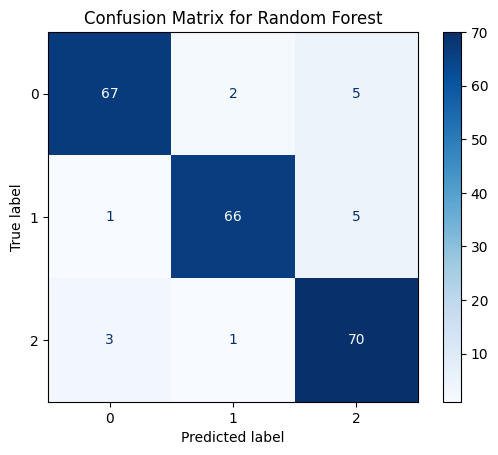

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Best model
best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]

# Predict on test set
y_pred_best = best_model.predict(X_test_enc)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()


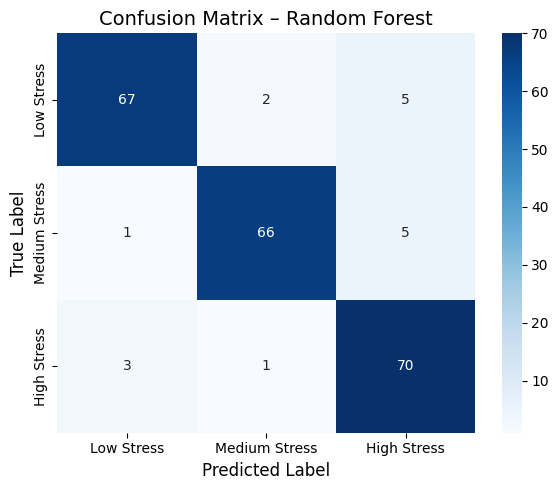

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix values from your image
cm = np.array([
    [67, 2, 5],
    [1, 66, 5],
    [3, 1, 70]
])

# Label mapping
labels = ["Low Stress", "Medium Stress", "High Stress"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix – Random Forest", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()


In [40]:
# ==============================
# Stress Prediction with CTGAN + ML & DL (Top-12 Correlation Features)
# ==============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Use scikeras for Keras model wrapper
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# SDV (CTGAN)
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ==============================
# 1. Load Dataset
# ==============================
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

target = "stress_level"

# ---- Top-12 most correlated with stress_level (from your heatmap) ----
selected_features = [
    "blood_pressure",
    "sleep_quality",
    "headache",
    "future_career_concerns",
    "study_load",
    "teacher_student_relationship",
    "basic_needs",
    "academic_performance",
    "social_support",
    "peer_pressure",
    "bullying",
    "safety",
]

df = df[selected_features + [target]].copy()

# ==============================
# 2. Train/Test Split
# ==============================
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df[target] = y_train

# ==============================
# 3. Metadata for CTGAN
# ==============================
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_df)

# Treat all selected features + target as categorical (matches your data design)
for col in selected_features:
    metadata.update_column(col, sdtype="categorical")
metadata.update_column(target, sdtype="categorical")

# ==============================
# 4. Train CTGAN
# ==============================
synthesizer = CTGANSynthesizer(
    metadata,
    epochs=300,
    batch_size=128,
    generator_dim=(128, 128),
    discriminator_dim=(128, 128),
    pac=1,
)

print("Training CTGAN...")
synthesizer.fit(train_df)
print("CTGAN training complete.")

# ==============================
# 5. Generate Synthetic Data
# ==============================
synthetic_data = synthesizer.sample(num_rows=len(train_df))
train_df_aug = pd.concat([train_df, synthetic_data], axis=0).sample(frac=1, random_state=42)

X_train_aug = train_df_aug.drop(columns=[target])
y_train_aug = train_df_aug[target]

# ==============================
# 6. Preprocessing (robust to no numeric cols)
# ==============================
# Infer numeric vs categorical from dtypes (but our list is all categorical)
numeric_cols = [c for c in selected_features if np.issubdtype(df[c].dtype, np.number)]
categorical_cols = [c for c in selected_features if c not in numeric_cols]

transformers = []
if numeric_cols:
    transformers.append(("num", StandardScaler(), numeric_cols))
if categorical_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers)

# Fit on augmented train, transform both
X_train_aug_enc = preprocessor.fit_transform(X_train_aug)
X_test_enc = preprocessor.transform(X_test)

# ==============================
# 7. Define Keras MLP Model
# ==============================
def build_keras_mlp(input_dim, output_dim):
    model = Sequential()
    model.add(Dense(128, activation="relu", input_dim=input_dim))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(output_dim, activation="softmax"))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# ==============================
# 8. Define Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "MLP (Sklearn)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42, eval_metric="mlogloss"
    ),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=-1, learning_rate=0.05, class_weight="balanced", random_state=42),
    "Deep MLP (Keras)": KerasClassifier(
        model=lambda: build_keras_mlp(X_train_aug_enc.shape[1], len(np.unique(y))),
        epochs=30,
        batch_size=32,
        verbose=0,
        random_state=42,
    ),
}

# ==============================
# 9. Train & Evaluate
# ==============================
results = []
for name, model in models.items():
    print(f"Training {name}...")
    try:
        model.fit(X_train_aug_enc, y_train_aug)
        y_pred = model.predict(X_test_enc)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})
    except Exception as e:
        print(f"❌ {name} failed: {e}")

# ==============================
# 10. Results
# ==============================
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("\nFinal Results:")
print(results_df)


Training CTGAN...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


CTGAN training complete.
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training MLP (Sklearn)...
Training Naive Bayes...
Training KNN...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 1760, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deep MLP (Keras)...

Final Results:
                 Model  Accuracy  Precision    Recall  F1-score
0        Random Forest  0.890909   0.891319  0.890909  0.890766
1                  KNN  0.886364   0.888889  0.886364  0.886650
2                  SVM  0.881818   0.884680  0.881818  0.881902
3    Gradient Boosting  0.881818   0.882746  0.881818  0.881708
4             LightGBM  0.877273   0.879311  0.877273  0.877211
5        MLP (Sklearn)  0.877273   0.877847  0.877273  0.877119
6     Deep MLP (Keras)  0.877273   0.879165  0.877273  0.877025
7              XGBoost  0.877273   0.880273  0.877273  0.877319
8  Logistic Regression  0.868182   0.868904  0.868182  0.868193
9          Naive Bayes  0.863636   0.867311  0.863636  0.863295


SHAP values shape (classes, samples, features): (3, 220, 12)

Top 20 OHE-level features by mean |SHAP| (overall):
                          feature_ohe  mean_abs_shap
0                 num__blood_pressure       0.709784
1           num__academic_performance       0.604046
2                  num__sleep_quality       0.438658
3                  num__peer_pressure       0.429974
4                         num__safety       0.385327
5                       num__headache       0.373826
6                 num__social_support       0.325392
7                       num__bullying       0.319061
8                    num__basic_needs       0.300728
9   num__teacher_student_relationship       0.281873
10                    num__study_load       0.254735
11        num__future_career_concerns       0.181643

Top 15 original features by mean |SHAP| (grouped):
       base_feature  mean_abs_shap
0             blood       0.709784
1          academic       0.604046
2             sleep       0.438658
3    

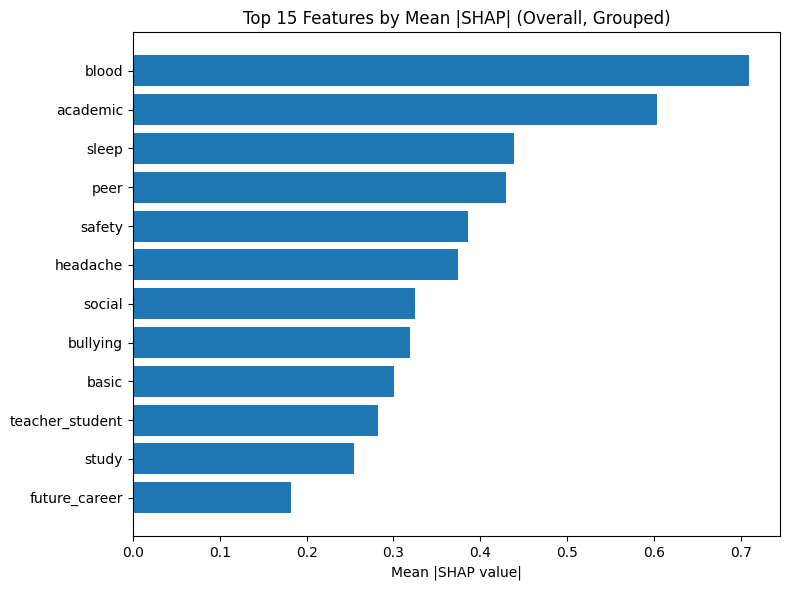

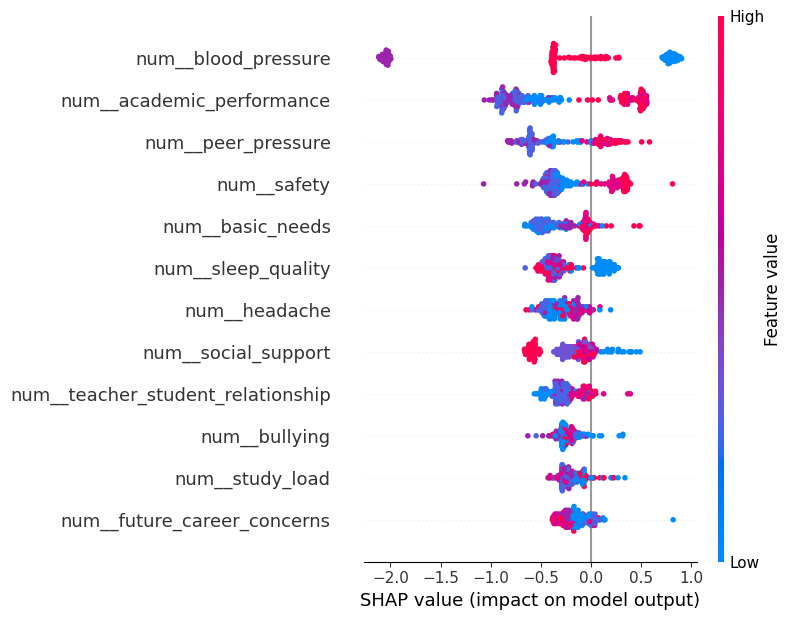

In [45]:
# ==============================
# SHAP: Overall Feature Importance Only (Multiclass aggregated)
# ==============================
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# ---- safety check: run after your preprocessing so these exist ----
for v in ["X_train_aug_enc", "X_test_enc", "y_train_aug", "y_test", "preprocessor"]:
    if v not in globals():
        raise RuntimeError(f"Variable '{v}' not found. Run your preprocessing code first.")

# 1) Train a strong tree model for SHAP
xgb_shap = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
    reg_lambda=1.0, objective="multi:softprob", eval_metric="mlogloss",
    tree_method="hist", random_state=42
)
xgb_shap.fit(X_train_aug_enc, y_train_aug)

# 2) SHAP explainer & values
explainer = shap.TreeExplainer(xgb_shap)
shap_values_raw = explainer.shap_values(X_test_enc)

# Normalize to shape: (n_classes, n_samples, n_features)
if isinstance(shap_values_raw, list):
    shap_values = np.stack(shap_values_raw, axis=0)
else:
    shap_values = np.transpose(shap_values_raw, (2, 0, 1))

print("SHAP values shape (classes, samples, features):", shap_values.shape)

# 3) Feature names from ColumnTransformer
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = preprocessor.get_feature_names()
feature_names = np.array(feature_names)

# 4) Overall importance at OHE-column level
#    Average mean |SHAP| across classes -> one global score per feature
abs_mean_per_class = np.mean(np.abs(shap_values), axis=1)   # (n_classes, n_features)
abs_mean_overall   = np.mean(abs_mean_per_class, axis=0)    # (n_features,)

ohe_importance_df = (
    pd.DataFrame({"feature_ohe": feature_names, "mean_abs_shap": abs_mean_overall})
      .sort_values("mean_abs_shap", ascending=False)
      .reset_index(drop=True)
)

print("\nTop 20 OHE-level features by mean |SHAP| (overall):")
print(ohe_importance_df.head(20))

# 5) Group OHE columns back to original features
def base_feature_name(ohe_name: str) -> str:
    # Strip transformer prefix
    tail = ohe_name.split("__", 1)[-1] if "__" in ohe_name else ohe_name
    if "=" in tail:
        return tail.split("=", 1)[0]
    # Heuristic: drop only the final underscore chunk (category)
    if "_" in tail:
        parts = tail.rsplit("_", 1)
        if len(parts) == 2:
            return parts[0]
    return tail

group_map = [base_feature_name(fn) for fn in feature_names]
group_df = pd.DataFrame({"base_feature": group_map, "mean_abs_shap": abs_mean_overall})
group_importance = (
    group_df.groupby("base_feature", as_index=False)["mean_abs_shap"].sum()
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
)

print("\nTop 15 original features by mean |SHAP| (grouped):")
print(group_importance.head(15))

# 6) Plots (overall only)
# 6a) Grouped global bar
plt.figure(figsize=(8, 6))
plt.barh(group_importance["base_feature"].head(15)[::-1],
         group_importance["mean_abs_shap"].head(15)[::-1])
plt.title("Top 15 Features by Mean |SHAP| (Overall, Grouped)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

# 6b) Overall beeswarm (aggregate across classes)
overall_shap = np.sum(shap_values, axis=0)  # (n_samples, n_features)
shap.summary_plot(overall_shap, features=X_test_enc, feature_names=feature_names, show=True)

# (Optional) save tables
# ohe_importance_df.to_csv("shap_ohe_importance.csv", index=False)
# group_importance.to_csv("shap_grouped_importance.csv", index=False)



Top 12 original features by mean |SHAP| (grouped, full names):
                    base_feature  mean_abs_shap
0                 blood_pressure       0.709784
1           academic_performance       0.604046
2                  sleep_quality       0.438658
3                  peer_pressure       0.429974
4                         safety       0.385327
5                       headache       0.373826
6                 social_support       0.325392
7                       bullying       0.319061
8                    basic_needs       0.300728
9   teacher_student_relationship       0.281873
10                    study_load       0.254735
11        future_career_concerns       0.181643


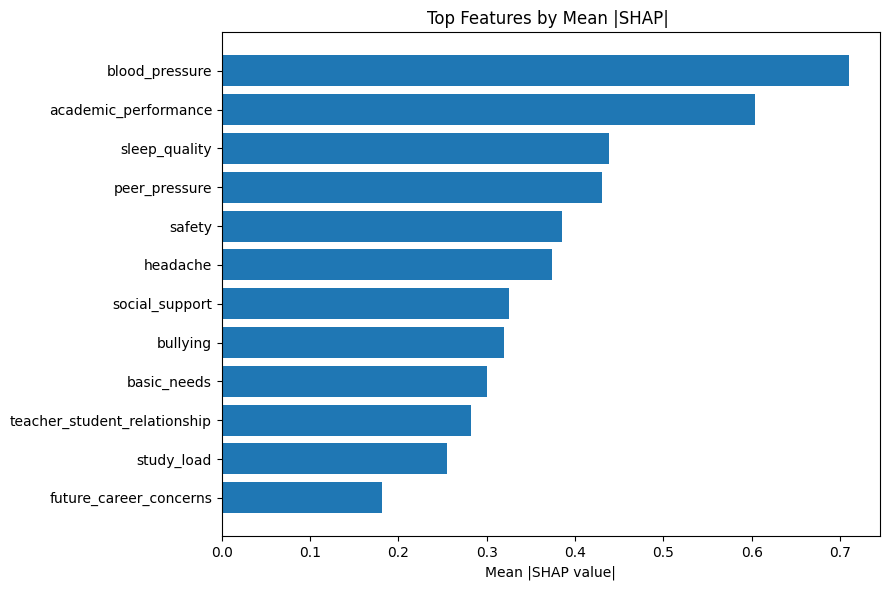

In [47]:
# ==============================
# 5) Group OHE columns back to original features (SAFE: keeps full names)
# ==============================
import re

# Get the original feature names that went into the ColumnTransformer
base_features = []
for name, trans, cols in preprocessor.transformers_:
    if isinstance(cols, (list, np.ndarray)):
        base_features.extend(list(cols))

# Build a regex that matches any full base feature at the start of the OHE name,
# optionally preceded by "<transformer>__" and optionally followed by "_<category>" or "=<category>"
pattern = r'^(?:[^_]+__)?(' + '|'.join(map(re.escape, base_features)) + r')(?:[_=].*)?$'
base_re = re.compile(pattern)

def base_feature_name(ohe_name: str) -> str:
    m = base_re.match(ohe_name)
    return m.group(1) if m else ohe_name

group_map = [base_feature_name(fn) for fn in feature_names]
group_df = pd.DataFrame({"base_feature": group_map, "mean_abs_shap": abs_mean_overall})
group_importance = (
    group_df.groupby("base_feature", as_index=False)["mean_abs_shap"].sum()
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
)

print("\nTop 12 original features by mean |SHAP| (grouped, full names):")
print(group_importance.head(12))

# ==============================
# 6) Plots (overall only) — show TOP 12 with full labels
# ==============================
TOPK = 12

plt.figure(figsize=(9, 6))
plt.barh(group_importance["base_feature"].head(TOPK)[::-1],
         group_importance["mean_abs_shap"].head(TOPK)[::-1])
plt.title("Top Features by Mean |SHAP| ")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()


Training CTGAN...
CTGAN training complete.
Class weights: {np.int64(0): np.float64(1.0238510762070971), np.int64(1): np.float64(0.9977324263038548), np.int64(2): np.float64(0.9794101279910963)}

🔎 Tuning RandomForest ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best RandomForest score (CV acc): 0.9040
Best RandomForest params: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 543}

🔎 Tuning SVM ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best SVM score (CV acc): 0.8966
Best SVM params: {'C': np.float64(7.074693032602092), 'gamma': 'auto', 'kernel': 'rbf'}

🔎 Tuning MLP ...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best MLP score (CV acc): 0.8966
Best MLP params: {'alpha': np.float64(0.006085448519014384), 'hidden_layer_sizes': (256, 128), 'learning_rate_init': np.float64(0.002352496259847715)}

🔎 Tuning XGBoost ...
Fitting 5 folds for each of 25 candidates, totalling 125

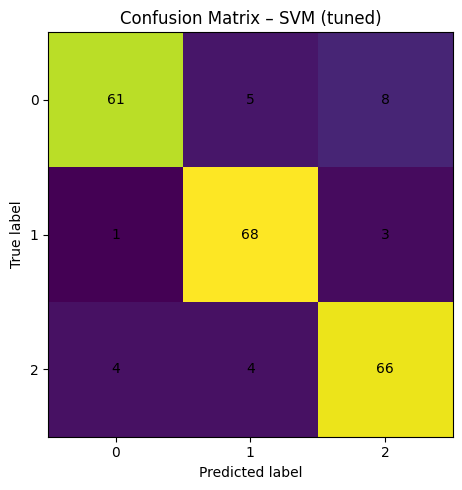

In [42]:
# ==============================
# Stress Prediction with CTGAN + Tuned Models + Full Metrics & Confusion Matrix
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings("ignore")

# Optional: deep MLP via scikeras (kept here but not tuned; you can add if needed)
# from scikeras.wrappers import KerasClassifier
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout

# SDV (CTGAN)
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ------------------------------
# 0. Config
# ------------------------------
CSV_PATH = "/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv"
TARGET = "stress_level"

# Top-12 most correlated with stress_level (from your heatmap)
SELECTED_FEATURES = [
    "blood_pressure", "sleep_quality", "headache", "future_career_concerns",
    "study_load", "teacher_student_relationship", "basic_needs",
    "academic_performance", "social_support", "peer_pressure",
    "bullying", "safety",
]

RANDOM_STATE = 42
TEST_SIZE = 0.20
CTGAN_EPOCHS = 300
SYNTHETIC_RATIO = 1.0  # 1.0 = generate as many synthetic rows as real train rows

# ------------------------------
# 1. Load data & split
# ------------------------------
df = pd.read_csv(CSV_PATH)
df = df[SELECTED_FEATURES + [TARGET]].copy()

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

train_df = X_train.copy()
train_df[TARGET] = y_train

# ------------------------------
# 2. CTGAN metadata & training
# ------------------------------
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=train_df)

# treat all selected features + target as categorical
for col in SELECTED_FEATURES:
    metadata.update_column(col, sdtype="categorical")
metadata.update_column(TARGET, sdtype="categorical")

synthesizer = CTGANSynthesizer(
    metadata,
    epochs=CTGAN_EPOCHS,
    batch_size=128,
    generator_dim=(128, 128),
    discriminator_dim=(128, 128),
    pac=1,
)

print("Training CTGAN...")
synthesizer.fit(train_df)
print("CTGAN training complete.")

# ------------------------------
# 3. Generate synthetic data & augment
# ------------------------------
num_synth = int(len(train_df) * SYNTHETIC_RATIO)
synthetic_data = synthesizer.sample(num_rows=num_synth)

train_df_aug = pd.concat([train_df, synthetic_data], axis=0).sample(frac=1, random_state=RANDOM_STATE)
X_train_aug = train_df_aug.drop(columns=[TARGET])
y_train_aug = train_df_aug[TARGET]

# ------------------------------
# 4. Preprocessing (OHE for cats, scale nums if any)
# ------------------------------
numeric_cols = [c for c in SELECTED_FEATURES if np.issubdtype(df[c].dtype, np.number)]
categorical_cols = [c for c in SELECTED_FEATURES if c not in numeric_cols]

transformers = []
if numeric_cols:
    transformers.append(("num", StandardScaler(), numeric_cols))
if categorical_cols:
    # Using 'sparse_output=False' for sklearn >=1.2; if your env is older, use sparse=False
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    transformers.append(("cat", ohe, categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers)

X_train_aug_enc = preprocessor.fit_transform(X_train_aug)
X_test_enc = preprocessor.transform(X_test)

# ------------------------------
# 5. Class weights
# ------------------------------
classes = np.unique(y_train_aug)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_aug)
class_weight_dict = {cls: w for cls, w in zip(classes, cw)}
print("Class weights:", class_weight_dict)

def add_class_weight_if_supported(estimator, cw_dict):
    if hasattr(estimator, "get_params") and "class_weight" in estimator.get_params():
        estimator.set_params(class_weight=cw_dict)

# ------------------------------
# 6. Search spaces & tuning helper
# ------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf_params = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(6, 24),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["sqrt", "log2"],
}

svm = SVC(probability=True, random_state=RANDOM_STATE)
svm_params = {
    "C": uniform(0.1, 50),
    "gamma": ["scale", "auto"],
    "kernel": ["rbf"],
}

mlp = MLPClassifier(max_iter=600, early_stopping=True, random_state=RANDOM_STATE)
mlp_params = {
    "hidden_layer_sizes": [(256,128), (200,100), (150,75)],
    "alpha": uniform(1e-5, 1e-2),
    "learning_rate_init": uniform(1e-4, 5e-3),
}

xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    tree_method="hist",
)
xgb_params = {
    "n_estimators": randint(300, 900),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "reg_lambda": uniform(0.5, 2.0),
}

lgbm = LGBMClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)
lgbm_params = {
    "n_estimators": randint(400, 1200),
    "num_leaves": randint(15, 255),
    "max_depth": randint(-1, 18),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_samples": randint(5, 50),
    "reg_lambda": uniform(0.5, 2.0),
}

add_class_weight_if_supported(rf, class_weight_dict)
add_class_weight_if_supported(svm, class_weight_dict)
add_class_weight_if_supported(mlp, class_weight_dict)

def tune(name, est, params, X, y, n_iter=25):
    print(f"\n🔎 Tuning {name} ...")
    search = RandomizedSearchCV(
        est, params, n_iter=n_iter, scoring="accuracy",
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
        error_score="raise"
    )
    fit_params = {}
    if isinstance(est, XGBClassifier):
        fit_params = {"eval_set": [(X, y)]}
    if isinstance(est, LGBMClassifier):
        fit_params = {
            "eval_set": [(X, y)],
            "eval_metric": "multi_logloss",
            "callbacks": [
                lgb.log_evaluation(0),          # silence logging
                # lgb.early_stopping(50),       # enable if you want early stopping during CV
            ],
        }
    search.fit(X, y, **fit_params)
    print(f"Best {name} score (CV acc): {search.best_score_:.4f}")
    print(f"Best {name} params: {search.best_params_}")
    return search.best_estimator_, search.best_params_, search.best_score_

best_rf, rf_best_params, rf_cv = tune("RandomForest", rf, rf_params, X_train_aug_enc, y_train_aug)
best_svm, svm_best_params, svm_cv = tune("SVM", svm, svm_params, X_train_aug_enc, y_train_aug)
best_mlp, mlp_best_params, mlp_cv = tune("MLP", mlp, mlp_params, X_train_aug_enc, y_train_aug)
best_xgb, xgb_best_params, xgb_cv = tune("XGBoost", xgb, xgb_params, X_train_aug_enc, y_train_aug)
best_lgbm, lgbm_best_params, lgbm_cv = tune("LightGBM", lgbm, lgbm_params, X_train_aug_enc, y_train_aug)

# ------------------------------
# 7. Evaluate tuned models
# ------------------------------
def evaluate_model(name, model, Xte, yte):
    y_pred = model.predict(Xte)
    acc = accuracy_score(yte, y_pred)
    prec = precision_score(yte, y_pred, average="weighted", zero_division=0)
    rec = recall_score(yte, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(yte, y_pred, average="weighted", zero_division=0)
    report = classification_report(yte, y_pred, zero_division=0)
    return {
        "Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1,
        "Report": report, "Pred": y_pred
    }

evals = []
for nm, md in [
    ("RandomForest (tuned)", best_rf),
    ("SVM (tuned)", best_svm),
    ("MLP (tuned)", best_mlp),
    ("XGBoost (tuned)", best_xgb),
    ("LightGBM (tuned)", best_lgbm),
]:
    evals.append(evaluate_model(nm, md, X_test_enc, y_test))

evals_df = pd.DataFrame([{k: v for k, v in e.items() if k not in ("Report", "Pred")} for e in evals])
evals_df = evals_df.sort_values("F1", ascending=False).reset_index(drop=True)
print("\n=== Tuned Models: Test Metrics ===")
print(evals_df[["Model", "Accuracy", "Precision", "Recall", "F1"]])

# ------------------------------
# 8. Stacking ensemble
# ------------------------------
stack = StackingClassifier(
    estimators=[
        ("xgb", best_xgb),
        ("lgbm", best_lgbm),
        ("svm", best_svm),
    ],
    final_estimator=LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE),
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False
)
print("\nTraining Stacking Ensemble...")
stack.fit(X_train_aug_enc, y_train_aug)
stack_eval = evaluate_model("Stacking (XGB + LGBM + SVM)", stack, X_test_enc, y_test)
print("\n=== Stacking: Test Metrics ===")
print(pd.DataFrame([{
    "Model": stack_eval["Model"],
    "Accuracy": stack_eval["Accuracy"],
    "Precision": stack_eval["Precision"],
    "Recall": stack_eval["Recall"],
    "F1": stack_eval["F1"],
}]))

# Combine & pick best by weighted F1
all_evals = evals + [stack_eval]
best_entry = max(all_evals, key=lambda e: e["F1"])
best_name = best_entry["Model"]
best_pred = best_entry["Pred"]
print(f"\n🏆 Best model by weighted F1: {best_name}")
print(f"Accuracy: {best_entry['Accuracy']:.4f} | Precision: {best_entry['Precision']:.4f} | Recall: {best_entry['Recall']:.4f} | F1: {best_entry['F1']:.4f}\n")
print("Classification Report:\n", best_entry["Report"])

# If best is one of the tuned single models, print its hyperparameters too
best_params_map = {
    "RandomForest (tuned)": rf_best_params,
    "SVM (tuned)": svm_best_params,
    "MLP (tuned)": mlp_best_params,
    "XGBoost (tuned)": xgb_best_params,
    "LightGBM (tuned)": lgbm_best_params,
}
if best_name in best_params_map:
    print("Best model hyperparameters:\n", best_params_map[best_name])

# ------------------------------
# 9. Confusion matrix for best model
# ------------------------------
labels_sorted = sorted(classes)  # ensure consistent order
cm = confusion_matrix(y_test, best_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title(f"Confusion Matrix – {best_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(len(labels_sorted)))
ax.set_yticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted)
ax.set_yticklabels(labels_sorted)

# annotate counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


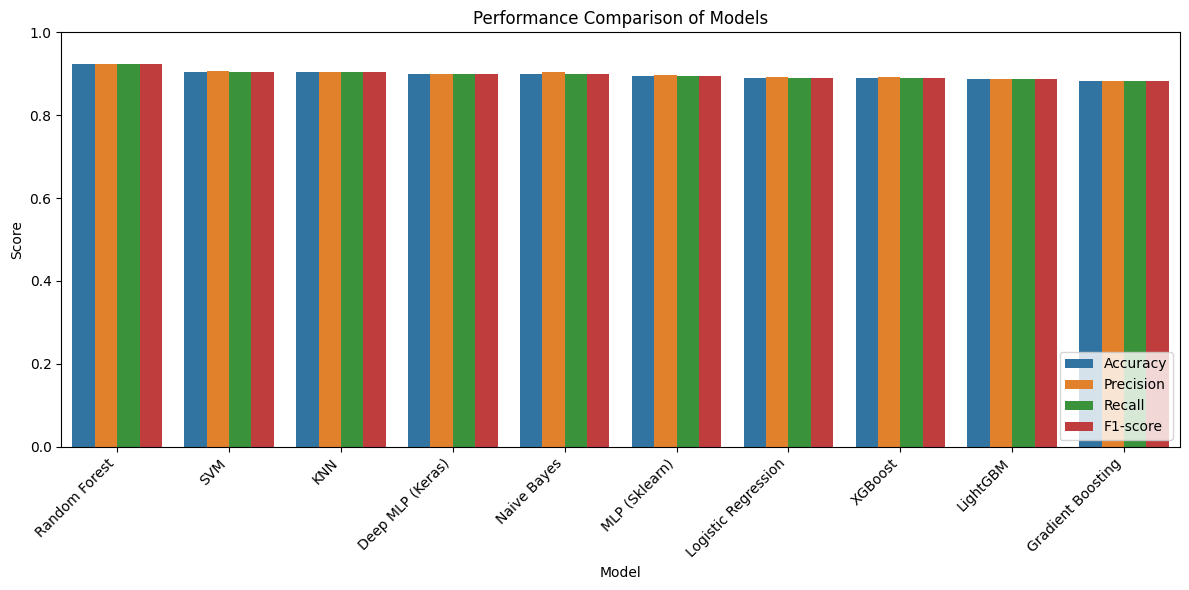

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
results_melted = results_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.xticks(rotation=45, ha='right')
plt.title("Performance Comparison of Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


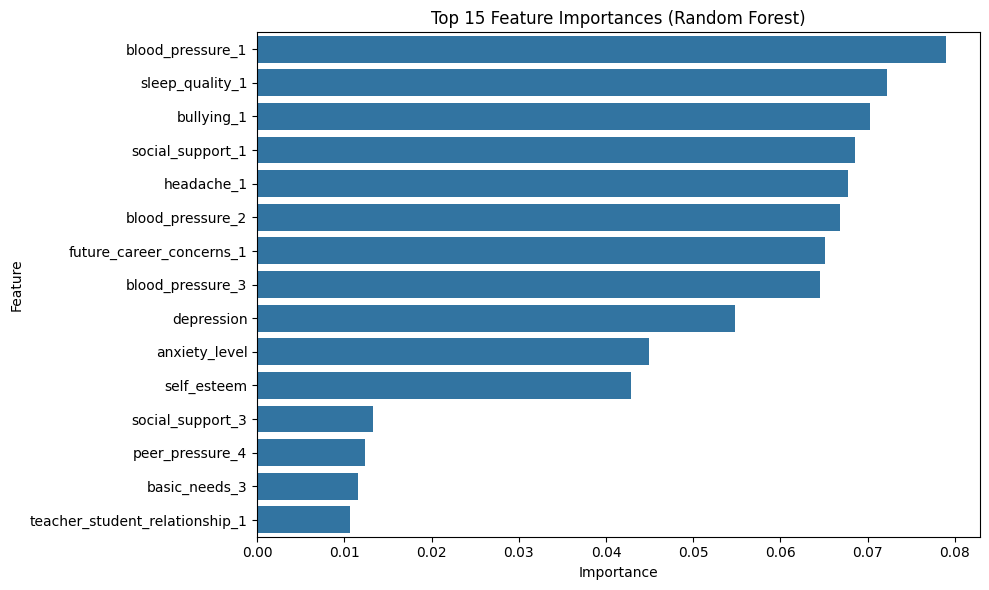

In [ ]:
importances = best_model.feature_importances_  # works for tree-based models
feature_names = numerical_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out())

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15))
plt.title(f"Top 15 Feature Importances ({best_model_name})")
plt.tight_layout()
plt.show()


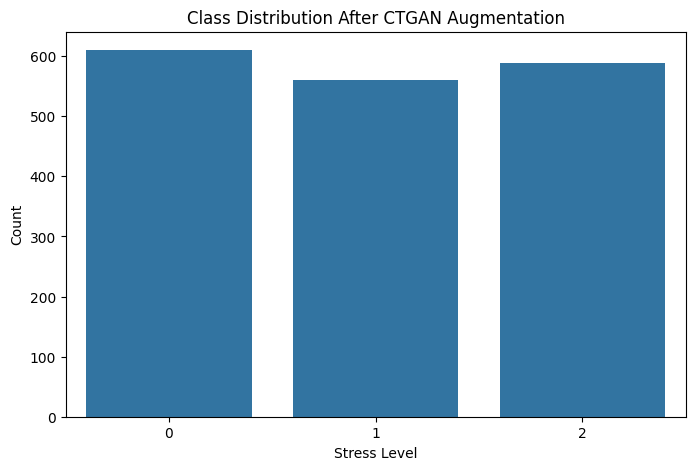

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_aug)
plt.title("Class Distribution After CTGAN Augmentation")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()


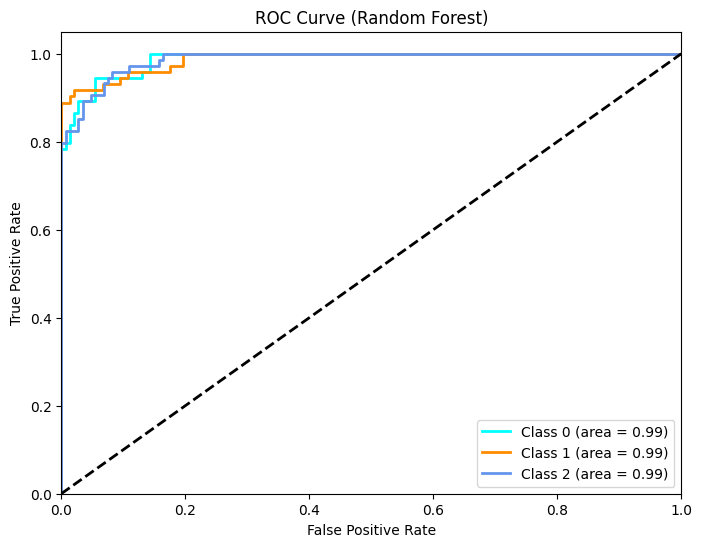

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize labels for multi-class
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = best_model.predict_proba(X_test_enc)

fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_score.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve ({best_model_name})')
plt.legend(loc="lower right")
plt.show()


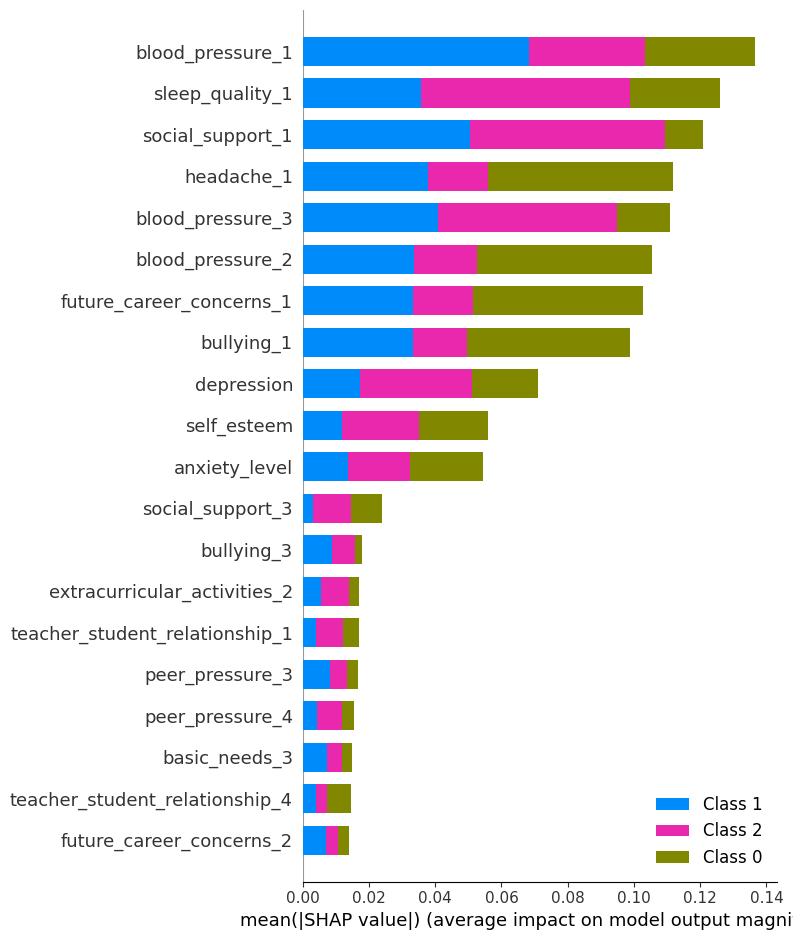

In [ ]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_enc)

shap.summary_plot(shap_values, X_test_enc, feature_names=feature_names, plot_type="bar")


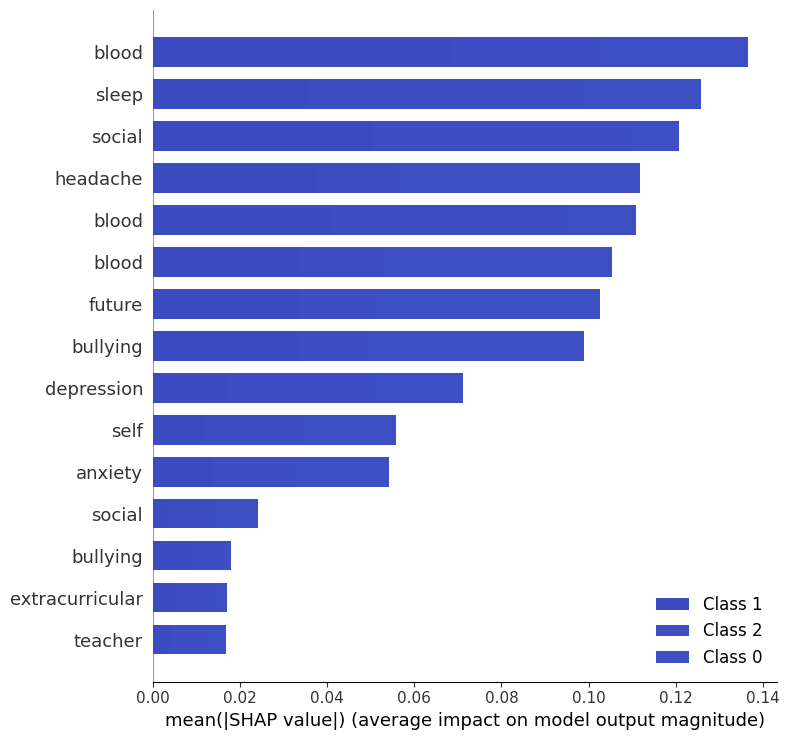

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Example: assuming best_model is Random Forest or tree-based
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_enc)

# Get original feature names from preprocessor
feature_names = numerical_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out())

# Clean feature names (remove numeric suffixes like _1, _2)
clean_feature_names = [name.split('_')[0] for name in feature_names]

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=clean_feature_names,
    plot_type="bar",
    color_bar=True,               # adds a color bar
    max_display=15,               # top 20 features
    color=plt.cm.coolwarm         # better color map
)


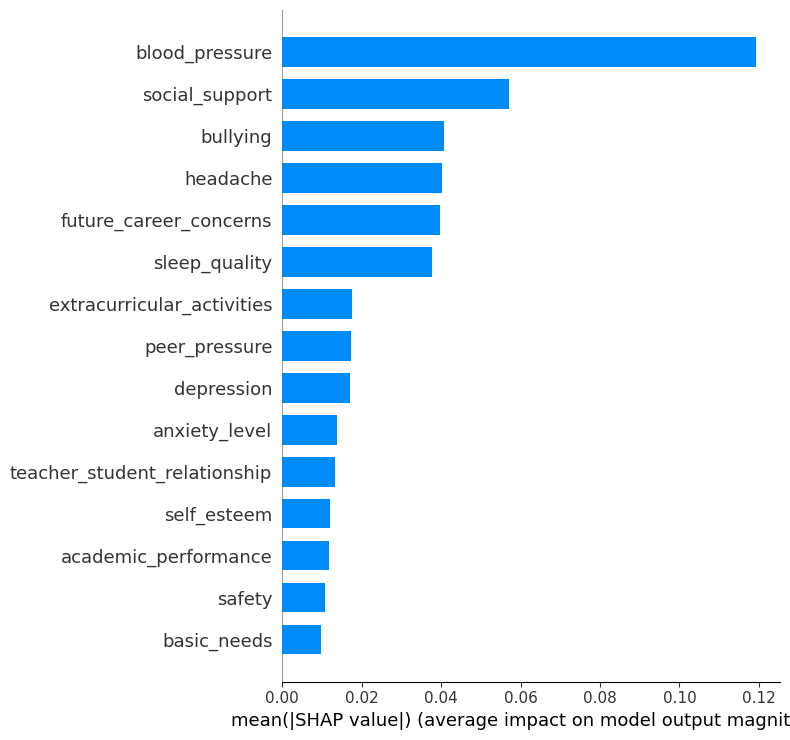

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np

# Selected features
selected_features = ['self_esteem', 'anxiety_level', 'depression',
                     'bullying', 'blood_pressure', 'sleep_quality',
                     'future_career_concerns', 'headache', 'academic_performance',
                     'extracurricular_activities', 'teacher_student_relationship',
                     'basic_needs', 'safety', 'peer_pressure', 'social_support',
                     'noise_level', 'study_load', 'living_conditions',
                     'breathing_problem', 'mental_health_history']

# Clean feature names
feature_names = numerical_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out())
clean_feature_names = [re.sub(r'_\d+$', '', name) for name in feature_names]

# Convert X_test_enc to DataFrame
X_test_df = pd.DataFrame(X_test_enc, columns=clean_feature_names)

# Keep only selected features
existing_features = [f for f in selected_features if f in X_test_df.columns]
X_selected = X_test_df[existing_features]

# SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values_full = explainer.shap_values(X_test_df)

# Handle multi-class
if isinstance(shap_values_full, list):
    shap_values_class = shap_values_full[1]
else:
    shap_values_class = shap_values_full[:, :, 1]

# Convert to DataFrame
shap_values_df = pd.DataFrame(shap_values_class, columns=clean_feature_names)

# Aggregate duplicated columns (from one-hot encoding)
shap_values_selected = shap_values_df[existing_features].T.groupby(level=0).sum().T

# Plot SHAP summary (bar)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_selected.values,
    shap_values_selected,
    feature_names=shap_values_selected.columns.tolist(),
    plot_type="bar",
    max_display=len(shap_values_selected.columns)
)


In [ ]:
!pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.8 MB/s eta 0:00:00


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Take a small sample of encoded test set
# -----------------------------
X_test_sample = X_test_enc[:50]

# Convert to dense if sparse
if hasattr(X_test_sample, "toarray"):
    X_test_sample = X_test_sample.toarray()

# Ensure float type
X_test_sample = X_test_sample.astype(float)

# -----------------------------
# TreeExplainer for Random Forest
# -----------------------------
best_model = models["Random Forest"]
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)  # list of arrays for multi-class

# Get feature names after OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
feature_names = np.concatenate([numerical_cols, ohe_feature_names])

# -----------------------------
# Plot SHAP summary for each class
# -----------------------------
for i, class_shap in enumerate(shap_values):
    print(f"\nClass {i} feature importance:")

    # Check shape
    print("SHAP shape:", class_shap.shape, "X_test_sample shape:", X_test_sample.shape)

    # If shape mismatch, transpose
    if class_shap.shape != X_test_sample.shape:
        class_shap = class_shap.T

    shap.summary_plot(class_shap, X_test_sample, feature_names=feature_names, plot_type="bar")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!pip install imbalanced-learn


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import numpy as np

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

target = 'stress_level'
selected_features = ['self_esteem', 'anxiety_level', 'depression', 'bullying',
                     'blood_pressure', 'sleep_quality', 'future_career_concerns',
                     'headache', 'academic_performance', 'extracurricular_activities',
                     'teacher_student_relationship', 'basic_needs', 'safety',
                     'peer_pressure', 'social_support']

df = df[selected_features + [target]]

# -------------------------------
# Encode categorical features
# -------------------------------
categorical_cols = ['bullying', 'blood_pressure', 'sleep_quality',
                    'future_career_concerns', 'headache', 'academic_performance',
                    'extracurricular_activities', 'teacher_student_relationship',
                    'basic_needs', 'safety', 'peer_pressure', 'social_support']

encoder = OrdinalEncoder()
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

# -------------------------------
# Split features and target
# -------------------------------
X = df.drop(columns=[target])
y = df[target]

# -------------------------------
# Train/test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# Apply SMOTE to generate synthetic training data
# -------------------------------
smote = SMOTE(random_state=42)
X_train_synth, y_train_synth = smote.fit_resample(X_train, y_train)

# -------------------------------
# Standardize numerical features for DL/SVM
# -------------------------------
numerical_cols = ['self_esteem', 'anxiety_level', 'depression']
scaler = StandardScaler()
X_train_synth[numerical_cols] = scaler.fit_transform(X_train_synth[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# -------------------------------
# Define models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "MLP Neural Network": MLPClassifier(hidden_layer_sizes=(50,50), max_iter=200)
}

# -------------------------------
# Train & Evaluate
# -------------------------------
results = []
for name, model in models.items():
    model.fit(X_train_synth, y_train_synth)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

# -------------------------------
# Display results
# -------------------------------
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1-score
2    Gradient Boosting  0.890909   0.891131  0.890909  0.890909
0  Logistic Regression  0.886364   0.886895  0.886364  0.886116
3                  SVM  0.881818   0.881537  0.881818  0.881348
1        Random Forest  0.877273   0.877119  0.877273  0.877086
4   MLP Neural Network  0.877273   0.877196  0.877273  0.877207


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Class 0 feature importance:
blood_pressure                  1.138103
social_support                  0.895983
academic_performance            0.332465
basic_needs                     0.292925
extracurricular_activities      0.190311
headache                        0.185262
self_esteem                     0.184186
safety                          0.175616
sleep_quality                   0.144349
depression                      0.126966
bullying                        0.122149
peer_pressure                   0.120415
teacher_student_relationship    0.104389
anxiety_level                   0.085066
future_career_concerns          0.008516
dtype: float64


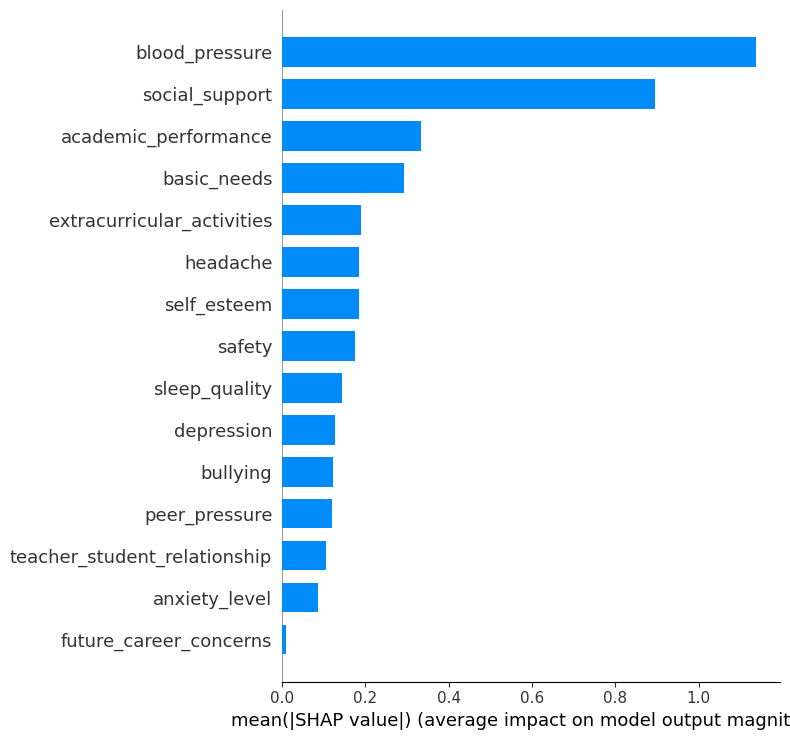


Class 1 feature importance:
blood_pressure                  2.312647
social_support                  1.194422
teacher_student_relationship    0.279066
self_esteem                     0.217211
bullying                        0.182771
headache                        0.166427
basic_needs                     0.161287
peer_pressure                   0.121967
anxiety_level                   0.118923
sleep_quality                   0.088542
safety                          0.075680
depression                      0.066206
extracurricular_activities      0.049257
future_career_concerns          0.040514
academic_performance            0.034590
dtype: float64


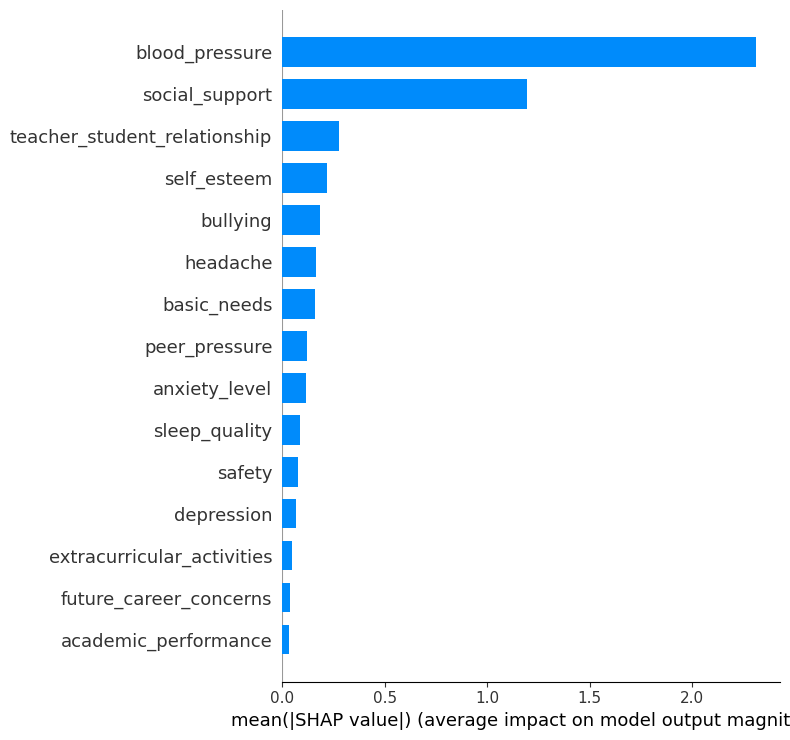


Class 2 feature importance:
blood_pressure                  1.174544
self_esteem                     0.401397
headache                        0.351689
bullying                        0.304921
social_support                  0.298439
academic_performance            0.297875
peer_pressure                   0.242382
sleep_quality                   0.232891
depression                      0.193172
teacher_student_relationship    0.174677
extracurricular_activities      0.141054
basic_needs                     0.131637
safety                          0.099936
future_career_concerns          0.049030
anxiety_level                   0.033857
dtype: float64


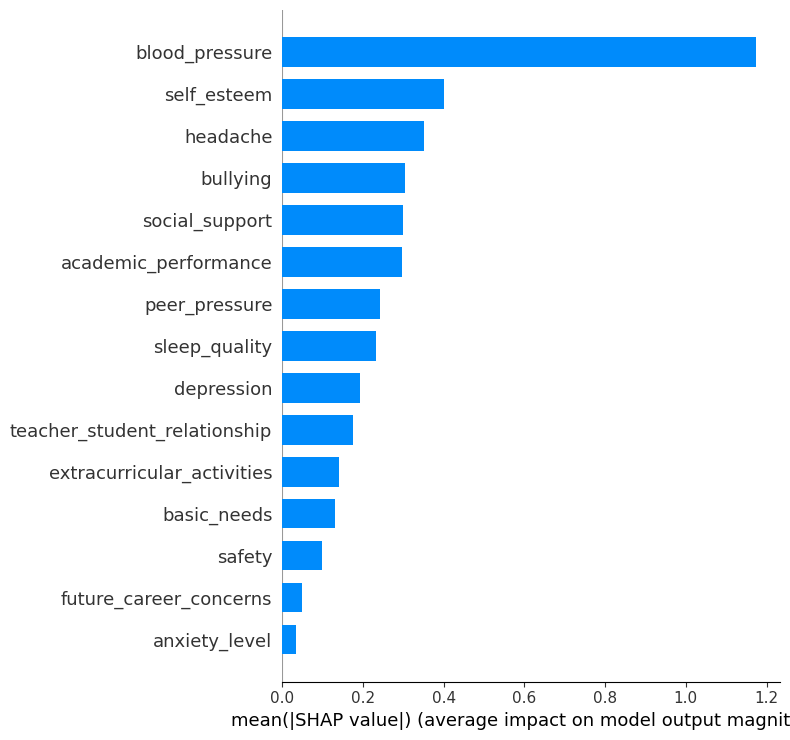

In [ ]:
import shap
import numpy as np
import pandas as pd

# Best model
best_model = models["Logistic Regression"]

# Small background sample
X_train_sample = X_train_synth.sample(n=50, random_state=42)
X_test_sample = X_test.iloc[:50]

# Create LinearExplainer
explainer = shap.LinearExplainer(best_model, X_train_sample)

# Compute SHAP values (3D array)
shap_values = explainer.shap_values(X_test_sample)  # shape=(n_samples, n_features, n_classes)

# If output is 3D, split by class
if shap_values.ndim == 3:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# Loop through each class
for class_idx, class_shap in enumerate(shap_values):
    print(f"\nClass {class_idx} feature importance:")

    # Convert to DataFrame and compute mean absolute SHAP
    class_shap_df = pd.DataFrame(class_shap, columns=selected_features)
    class_shap_mean = class_shap_df.abs().mean().sort_values(ascending=False)
    print(class_shap_mean)

    # SHAP summary bar plot
    shap.summary_plot(class_shap, X_test_sample, plot_type="bar", feature_names=selected_features, show=True)



Class 0 Feature Importance:
blood_pressure                  1.138103
social_support                  0.895983
academic_performance            0.332465
basic_needs                     0.292925
extracurricular_activities      0.190311
headache                        0.185262
self_esteem                     0.184186
safety                          0.175616
sleep_quality                   0.144349
depression                      0.126966
bullying                        0.122149
peer_pressure                   0.120415
teacher_student_relationship    0.104389
anxiety_level                   0.085066
future_career_concerns          0.008516
dtype: float64


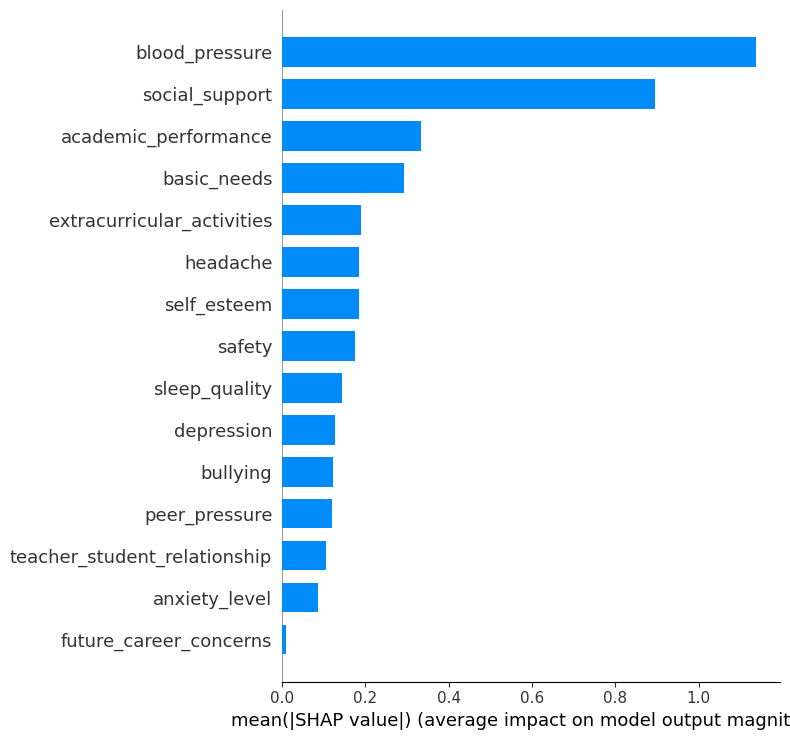

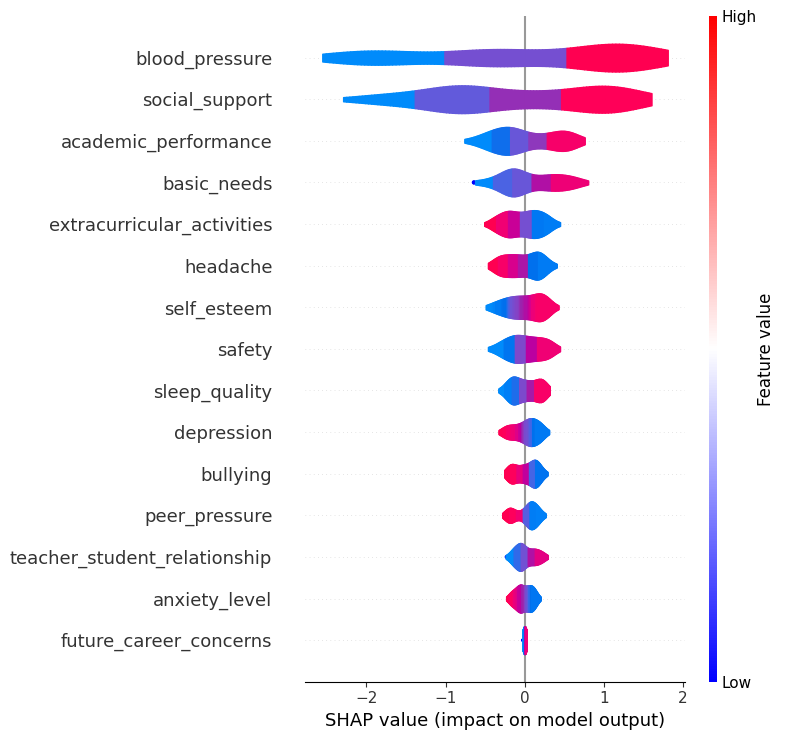


Class 1 Feature Importance:
blood_pressure                  2.312647
social_support                  1.194422
teacher_student_relationship    0.279066
self_esteem                     0.217211
bullying                        0.182771
headache                        0.166427
basic_needs                     0.161287
peer_pressure                   0.121967
anxiety_level                   0.118923
sleep_quality                   0.088542
safety                          0.075680
depression                      0.066206
extracurricular_activities      0.049257
future_career_concerns          0.040514
academic_performance            0.034590
dtype: float64


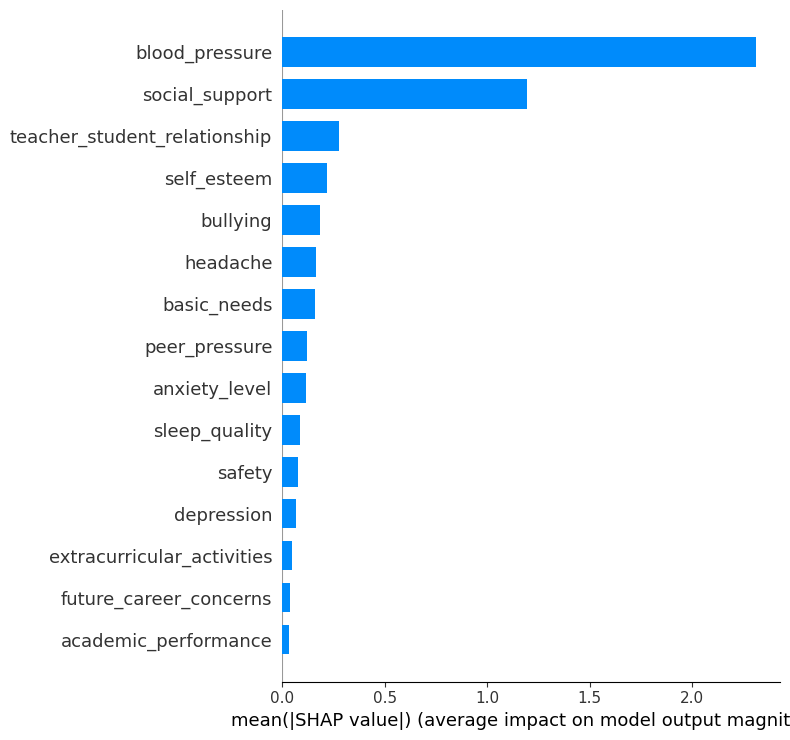

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

best_model = models["Logistic Regression"]

# Small background and test samples
X_train_sample = X_train_synth.sample(n=50, random_state=42)
X_test_sample = X_test.iloc[:50]

# Create LinearExplainer
explainer = shap.LinearExplainer(best_model, X_train_sample)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

# If output is 3D (multi-class), split by class
if shap_values.ndim == 3:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# Loop through each class
for class_idx, class_shap in enumerate(shap_values):
    print(f"\nClass {class_idx} Feature Importance:")

    # Convert to DataFrame and compute mean absolute SHAP
    class_shap_df = pd.DataFrame(class_shap, columns=selected_features)
    class_shap_mean = class_shap_df.abs().mean().sort_values(ascending=False)
    print(class_shap_mean)

    # -------------------------------
    # SHAP summary bar plot (two-color)
    # -------------------------------
    shap.summary_plot(
        class_shap,
        X_test_sample,
        plot_type="bar",
        feature_names=selected_features,
        cmap=plt.get_cmap("bwr"),  # <-- Use cmap instead of color
        show=True
    )

    # -------------------------------
    # SHAP beeswarm plot (two-color)
    # -------------------------------
    shap.summary_plot(
        class_shap,
        X_test_sample,
        feature_names=selected_features,
        plot_type="violin",
        cmap=plt.get_cmap("bwr"),  # <-- Use cmap here as well
        show=True
    )
